# Migration: the exercises, on the UN DESA migrant stock network

02805 Social Graphs and Interactions, weeks 1-4, worked on the group's own dataset.

A node is a country (ISO3 code). A directed, weighted arc runs origin &rarr; destination,
weight = number of people born in the origin living in the destination, from the UN DESA
**International Migrant Stock 2024** (Table 1, `data/migration_flows.tsv`). Snapshot year 2024,
232 countries with at least one measured arc.

We use this dataset instead of Marvel or the philosophers because it is directed, weighted,
and dense in a way that surfaces three standard traps as visible findings: DESA's table measures
reporting systems as much as migration, betweenness needs weak links cut first, and the raw
network's clustering and assortativity depend on that same choice. Each trap is demonstrated in
place below, with the numbers that show it.

## What this notebook covers

| Exercise | Covered | Notes |
|---|---|---|
| 1.6 | Yes | in/out-degree and strength distributions, USA/DNK reporting trap |
| 2.2 | Yes (same n,m part) | G(n,m) table, raw and 100k-threshold network |
| 2.6 | Yes | CCDF, BA and G(n,m) comparison, `powerlaw.Fit` |
| 2.8 | Yes | reciprocity, clustering under three nulls, transitivity, isolates |
| 2.9 | Yes | friendship paradox, formula check, weighted extension |
| 3.3 | Yes | threshold sweep, BFS (hand-written + validated), directed reachability |
| 3.5 | Yes | degree/closeness/harmonic/betweenness top tens, outliers |
| 3.7 | Yes | PageRank (hand-written power iteration + validated), vs in-degree |
| 3.8 | Yes | 200-shuffle z-scores for betweenness and closeness |
| 3.9 | Yes | degree assortativity, region/sub-region homophily |
| Cliques | Yes | clique number on the 100k network, vs raw network's 43 |
| 4.5 | Yes | Louvain, 5 seeds, NMI vs region, greedy modularity |
| 4.6 | Yes | Q shuffle test, matching G(n,p), stability comparison |
| 4.9 | Yes | Infomap (igraph) vs Louvain |
| 4.11 | Yes | hand-written disparity filter (validated), backbone figures |

**Skipped, paper-only (pen and paper by design):** 1.5, 2.3, 2.7, 3.2, 3.4, 3.6, 3.10, 4.1, 4.3,
4.7, 4.8, 4.10.

**Skipped, builder items (not notebook work):** 1.3, 1.8, 2.10, 2.11, 3.11, 3.12, 4.4, 4.12, 4.13,
and the 1.1/1.2/2.1/3.1/4.2 reading checks.

**Skipped, dataset-free sub-parts:** the pure G(n,p) sweeps (2.2's phase transition and 2-step
neighborhood picture), Watts-Strogatz, BA growth, karate club and the pure-noise Q vs n,k sweep all
live in `03_marvel_exercises.ipynb`, run once there; we do not repeat them here.

**Skipped, LLM-grading sub-items:** 2.6's "ask your favorite LLM", 2.9 item 4, 3.5 item 4, 3.7's
agent-explains-dangling-nodes framing (we explain it ourselves in code and prose instead).

**Skipped, cannot be supported by this dataset:** 4.9's link-clustering half (we run Infomap
instead, as the brief allows picking one); k-clique communities and 4.7/4.8's toy-network overlap
walkthrough (no natural k-clique structure at country granularity; the philosophers walkthrough in
the brief covers the concept).

In [1]:
import warnings
warnings.filterwarnings("ignore", module="powerlaw")  # its warnings print local install paths
import sys, json, time, random, math
from collections import Counter

sys.path.insert(0, "../analysis")

import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import powerlaw
from sklearn.metrics import normalized_mutual_info_score as nmi

from week03_country_networks import stock_network, core_of, largest_clique
from week04_staffing import tracked, louvain, shuffled_nmi, unweighted, infomap
from week04_where import disparity, check_disparity

# validated for colour-blind separation on all pairs (see notebook 01)
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#2B2B2B", "#6B6B6B", "#DDDDDD"

DATA = "../data"
SEED = 2805
THRESHOLD_100K = 100_000
DRAWS_28 = 100      # 2.8 clustering nulls
DRAWS_38 = 200      # 3.8 betweenness/closeness shuffles
DRAWS_39 = 200      # 3.9 assortativity shuffles
DRAWS_HOMOPHILY = 1000
DRAWS_46 = 20       # 4.6 Q shuffle test
RUNS_45 = 5         # 4.5 Louvain seeds

def style(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.tick_params(labelsize=8, colors=MUTED, length=0)
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)

FACTS = json.load(open("../analysis/week03_country_facts.json"))
print("oracle keys:", list(FACTS.keys()))

oracle keys: ['year', 'stock', 'refugees', 'stock_rankings', 'refugee_rankings', 'stock_threshold_sweep', 'destination_overlap', 'shared_countries']


## Setup

Two networks do all the work below: the **raw** network (every arc with `stock_2024 > 0`) and the
**100k** network (arcs above 100,000 people), used wherever the brief calls for paths, betweenness
or closeness. `D0`/`D100` keep direction and weight; `U0`/`U100` are `core_of(...)`, the undirected,
unweighted giant component, matching how `analysis/week03_country_networks.py` computed the oracle
numbers in `week03_country_facts.json`.

In [2]:
D0 = stock_network(0)
D100 = stock_network(THRESHOLD_100K)
U0 = core_of(D0)
U100 = core_of(D100)

print(f"D0   {D0.number_of_nodes()} nodes  {D0.number_of_edges()} arcs")
print(f"D100 {D100.number_of_nodes()} nodes  {D100.number_of_edges()} arcs")
print(f"U0 giant   {U0.number_of_nodes()} nodes  {U0.number_of_edges()} edges")
print(f"U100 giant {U100.number_of_nodes()} nodes  {U100.number_of_edges()} edges")

assert D0.number_of_nodes() == 232
assert D0.number_of_edges() == 9035
print("\nmatches oracle: 232 nodes, 9035 arcs at threshold 0")

# names, and the weighted undirected graph used from section 4 onward:
# both directions summed, built by hand because to_undirected() would keep
# only one direction's weight.
flows = pd.read_csv(f"{DATA}/migration_flows.tsv", sep="\t", comment="#")
name = dict(zip(flows.origin, flows.origin_name))
name.update(dict(zip(flows.destination, flows.destination_name)))
name = {k: v.rstrip("*") for k, v in name.items()}

W0 = nx.Graph()
W0.add_nodes_from(D0.nodes())
for u, v, w in D0.edges(data="weight"):
    if W0.has_edge(u, v):
        W0[u][v]["weight"] += w
    else:
        W0.add_edge(u, v, weight=w)

usa_mex = W0["USA"]["MEX"]["weight"]
print(f"\nUSA->MEX {D0['USA']['MEX']['weight']:,}   MEX->USA {D0['MEX']['USA']['weight']:,}   "
      f"W0 USA-MEX summed {usa_mex:,}   (both directions added, not one kept)")

D0   232 nodes  9035 arcs
D100 148 nodes  503 arcs
U0 giant   232 nodes  7198 edges
U100 giant 148 nodes  455 edges

matches oracle: 232 nodes, 9035 arcs at threshold 0



USA->MEX 823,502   MEX->USA 11,279,561   W0 USA-MEX summed 12,103,063   (both directions added, not one kept)


## 1.6: Who reports whom

In-degree counts how many origin countries a destination lists a stock for; out-degree counts how
many destinations list a stock from that origin. Both come from `D0`, the raw (threshold 0)
directed network. Because DESA's Table 1 is a reporting matrix, not a survey of every migrant,
in-degree measures a destination's statistical system as much as it measures migration: a
register-based country (Denmark) lists almost every origin with even one person, a survey-based
one (the USA) lists only the origins its survey samples catch.

In [3]:
in_deg = dict(D0.in_degree())
out_deg = dict(D0.out_degree())
in_str = dict(D0.in_degree(weight="weight"))
out_str = dict(D0.out_degree(weight="weight"))

print(f"USA in-degree {in_deg['USA']}   (survey-based, few named origins)")
print(f"DNK in-degree {in_deg['DNK']}  (register-based, almost every origin)")
print(f"for comparison, USA in-strength (people) {in_str['USA']:,}  -- the reporting-system gap")
print(f"                DNK in-strength (people) {in_str['DNK']:,}  does not show up in strength")

def top5(d):
    return [(name[c], v) for c, v in sorted(d.items(), key=lambda kv: -kv[1])[:5]]

print("\ntop 5 in-degree (origins listed)   ", top5(in_deg))
print("top 5 out-degree (destinations reached)", top5(out_deg))
print("top 5 in-strength (people)          ", top5(in_str))
print("top 5 out-strength (people)         ", top5(out_str))

USA in-degree 59   (survey-based, few named origins)
DNK in-degree 192  (register-based, almost every origin)
for comparison, USA in-strength (people) 48,855,624  -- the reporting-system gap
                DNK in-strength (people) 833,721  does not show up in strength

top 5 in-degree (origins listed)    [('Norway', 203), ('Australia', 197), ('Denmark', 192), ('Hungary', 184), ('Greece', 182)]
top 5 out-degree (destinations reached) [('United States of America', 161), ('China', 141), ('United Kingdom', 140), ('France', 132), ('India', 124)]
top 5 in-strength (people)           [('United States of America', 48855624), ('Germany', 13612825), ('Saudi Arabia', 13394579), ('Canada', 8805641), ('United Kingdom', 8730397)]
top 5 out-strength (people)          [('India', 18533845), ('China', 11701619), ('Mexico', 11596529), ('Ukraine', 9769216), ('Russian Federation', 9134094)]


**The trap.** Norway (203), Australia (197) and Denmark (192) top the in-degree leaderboard
because their registers name almost every origin country, including origins with a single person.
The USA, the destination with the largest migrant population (48.9 million, top in-strength), lists
only 59 named origins: its data comes from a household survey that resolves only the largest
source countries. In-degree here measures how a country counts. In-strength, which sums people
rather than counting origins, answers the question directly: the USA, Germany and Saudi Arabia
lead by volume. Every ranking from Part 3 onward that uses raw in-degree inherits this artefact,
which is why 3.3 onward switches to the 100k-threshold network.

## 2.2: A random network with the same n and m

$G(n,m)$ with the migration network's own node and edge count, on the raw undirected core and on
the 100k-threshold core. 20 draws each: average distance in the giant component, giant size,
isolates, maximum degree.

In [4]:
DRAWS_22 = 20

def gnm_table(n, m, seed, draws=DRAWS_22):
    rows = []
    for i in range(draws):
        g = nx.gnm_random_graph(n, m, seed=seed + i)
        giant = max(nx.connected_components(g), key=len)
        core = g.subgraph(giant)
        rows.append({
            "avg_dist_giant": nx.average_shortest_path_length(core),
            "giant_size": len(giant),
            "isolates": sum(1 for _, d in g.degree() if d == 0),
            "max_degree": max(d for _, d in g.degree()),
        })
    return pd.DataFrame(rows).mean()

n0, m0 = U0.number_of_nodes(), U0.number_of_edges()
n100, m100 = U100.number_of_nodes(), U100.number_of_edges()

gnm_raw = gnm_table(n0, m0, SEED)
gnm_100 = gnm_table(n100, m100, SEED + 1000)

table = pd.DataFrame({
    "real raw":  [FACTS["stock"]["mean_path"], FACTS["stock"]["giant"], 232 - n0, "n/a"],
    "G(n,m) raw (mean of 20)": [round(gnm_raw.avg_dist_giant, 3), round(gnm_raw.giant_size, 1),
                                  round(gnm_raw.isolates, 2), round(gnm_raw.max_degree, 1)],
    "real 100k": [FACTS["stock_threshold_sweep"][-1]["mean_path"], FACTS["stock_threshold_sweep"][-1]["giant"],
                  232 - n100, "n/a"],
    "G(n,m) 100k (mean of 20)": [round(gnm_100.avg_dist_giant, 3), round(gnm_100.giant_size, 1),
                                    round(gnm_100.isolates, 2), round(gnm_100.max_degree, 1)],
}, index=["avg distance (giant)", "giant size", "isolates (dropped by construction)", "max degree"])
print(table)

                                   real raw  G(n,m) raw (mean of 20)  \
avg distance (giant)                  1.746                    1.731   
giant size                              232                  232.000   
isolates (dropped by construction)        0                    0.000   
max degree                              n/a                   81.200   

                                   real 100k  G(n,m) 100k (mean of 20)  
avg distance (giant)                   2.931                     2.932  
giant size                               148                   147.400  
isolates (dropped by construction)        84                     0.600  
max degree                               n/a                    13.200  


The real raw network (n=232, m=7,198 undirected edges) has an average distance of 1.746 against a
random network's 1.731: close, because at this density ($\langle k\rangle \approx 62$) almost any
wiring reaches everyone in two hops. The 100k network is sparser (n=148, m=455,
$\langle k\rangle \approx 6$) and matches just as closely: 2.931 real against 2.932 random. The
100k network's clustering is modest enough at this threshold that $G(n,m)$'s lack of clustering
costs it little extra distance. The "isolates" trap differs from Marvel's here: `stock_network`
drops a country entirely once no arc survives the threshold, instead of leaving it as a zero-degree
node, so the 100k network's 84 missing countries (232 to 148) are absent from the network, never
counted as isolates.

## 2.6: Is it a power law

CCDF of in-degree and in-strength on log-log axes (no binning needed: the CCDF at $k$ is just the
fraction of nodes with degree $\ge k$, which needs no bin width to stay well-behaved in the tail).
Compared with a Barabasi-Albert network and a $G(n,m)$ network of the same size and mean degree.

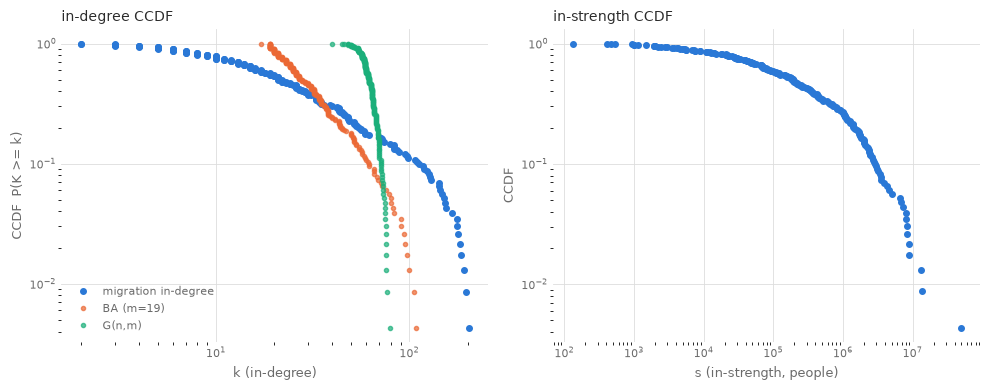

rough CCDF slope (k>=5) -0.919  ->  gamma ~ 1.92 (CCDF slope is 1-gamma for exponent gamma)
powerlaw.Fit on in-strength: alpha=2.15  xmin=1,387,343  loglikelihood ratio (power law vs lognormal) R=-0.708 p=0.493  (favors lognormal)


In [5]:
def ccdf(values):
    x = np.sort(np.asarray(values))[::-1]
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

k_in = np.array(list(in_deg.values()))
s_in = np.array([v for v in in_str.values() if v > 0])

mean_k_in = k_in.mean()
BA = nx.barabasi_albert_graph(232, m=max(1, round(mean_k_in / 2)), seed=SEED)
GNM_raw = nx.gnm_random_graph(232, U0.number_of_edges(), seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x, y = ccdf(k_in)
xba, yba = ccdf([d for _, d in BA.degree()])
xgnm, ygnm = ccdf([d for _, d in GNM_raw.degree()])
axes[0].plot(x, y, "o", color=BLUE, markersize=4, label="migration in-degree")
axes[0].plot(xba, yba, "o", color=ORANGE, markersize=3, alpha=0.7, label=f"BA (m={max(1, round(mean_k_in/2))})")
axes[0].plot(xgnm, ygnm, "o", color=GREEN, markersize=3, alpha=0.7, label="G(n,m)")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
style(axes[0], "k (in-degree)", "CCDF  P(K >= k)")
axes[0].set_title("in-degree CCDF", fontsize=10, color=INK, loc="left")
axes[0].legend(frameon=False, fontsize=8, labelcolor=MUTED)

xs, ys = ccdf(s_in)
axes[1].plot(xs, ys, "o", color=BLUE, markersize=4)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
style(axes[1], "s (in-strength, people)", "CCDF")
axes[1].set_title("in-strength CCDF", fontsize=10, color=INK, loc="left")
fig.tight_layout()
plt.show()

mask = x >= 5
slope, icept = np.polyfit(np.log10(x[mask]), np.log10(y[mask]), 1)
print(f"rough CCDF slope (k>=5) {slope:.3f}  ->  gamma ~ {1 - slope:.2f} (CCDF slope is 1-gamma for exponent gamma)")

fit = powerlaw.Fit(s_in, discrete=False, verbose=False)
R, p = fit.distribution_compare("power_law", "lognormal")
verdict = "favors lognormal" if R < 0 else "favors power law"
print(f"powerlaw.Fit on in-strength: alpha={fit.power_law.alpha:.2f}  xmin={fit.power_law.xmin:,.0f}  "
      f"loglikelihood ratio (power law vs lognormal) R={R:.3f} p={p:.3f}  ({verdict})")

The in-degree CCDF sits above the BA and $G(n,m)$ curves for small $k$ and falls off more slowly:
a rough tail slope gives $\gamma \approx 1.9$, in the heavy-tailed range on only 232 points, so the
tail is thin. It tops out at Norway's in-degree of 203 (from 1.6), a reporting artefact rather than
a hub built by migration volume. With n=232 there are only a handful of countries left to populate
that tail, the same finite-size effect week 1 saw on Marvel's 303 characters.
`powerlaw.Fit`'s likelihood-ratio test on in-strength (people, not link count) gives R=-0.71,
p=0.49: the negative R favors lognormal over power law, but p=0.49 means the test cannot separate
the two distributions on this data. The heavy tail is visible; its exact shape is not determined.

## 2.8: Compared to what, properly

On the **100k-threshold** undirected giant (`U100`) and its directed counterpart (`D100`): reciprocity
against a degree-preserving directed null; clustering against a configuration model (counting the
links self-loops/parallel edges cost), a $G(n,m)$, and a double-edge-swap null; transitivity and
isolates read off the same three nulls.

In [6]:
n_u100, m_u100 = U100.number_of_nodes(), U100.number_of_edges()
degseq100 = [d for _, d in U100.degree()]

recip_real = nx.reciprocity(D100)
n_d100, m_d100 = D100.number_of_nodes(), D100.number_of_edges()
gnm_density = m_d100 / (n_d100 * (n_d100 - 1))

recip_null = []
for i in tracked("directed degree-preserving null", 50):
    h = D100.copy()
    try:
        nx.directed_edge_swap(h, nswap=10 * m_d100, max_tries=1000 * m_d100, seed=SEED + i)
    except nx.NetworkXAlgorithmError:
        pass
    recip_null.append(nx.reciprocity(h))
recip_null = np.array(recip_null)

print(f"D100 reciprocity {recip_real:.4f}")
print(f"  G(n,m) directed expectation (density) {gnm_density:.4f}")
print(f"  ratio: {recip_real / gnm_density:.1f}x higher than the G(n,m) expectation")
print(f"  degree-preserving directed null: mean {recip_null.mean():.4f} sd {recip_null.std():.4f}  "
      f"z {(recip_real - recip_null.mean()) / recip_null.std():.2f}")

directed degree-preserving null: 5/50 (10%), 0s elapsed, about 6s left


directed degree-preserving null: 10/50 (20%), 1s elapsed, about 4s left


directed degree-preserving null: 15/50 (30%), 1s elapsed, about 4s left


directed degree-preserving null: 20/50 (40%), 2s elapsed, about 3s left


directed degree-preserving null: 25/50 (50%), 3s elapsed, about 3s left


...

directed degree-preserving null: 35/50 (70%), 3s elapsed, about 1s left


directed degree-preserving null: 40/50 (80%), 4s elapsed, about 1s left


directed degree-preserving null: 45/50 (90%), 4s elapsed, about 0s left


directed degree-preserving null: 50/50 (100%), 4s elapsed, about 0s left


D100 reciprocity 0.1909
  G(n,m) directed expectation (density) 0.0231
  ratio: 8.3x higher than the G(n,m) expectation
  degree-preserving directed null: mean 0.0449 sd 0.0105  z 13.96


configuration model: 10/100 (10%), 0s elapsed, about 0s left


configuration model: 20/100 (20%), 0s elapsed, about 0s left


configuration model: 30/100 (30%), 0s elapsed, about 0s left


configuration model: 40/100 (40%), 0s elapsed, about 0s left


configuration model: 50/100 (50%), 0s elapsed, about 0s left


...

double-edge-swap: 60/100 (60%), 2s elapsed, about 1s left


double-edge-swap: 70/100 (70%), 2s elapsed, about 1s left


double-edge-swap: 80/100 (80%), 3s elapsed, about 0s left


double-edge-swap: 90/100 (90%), 3s elapsed, about 0s left


double-edge-swap: 100/100 (100%), 4s elapsed, about 0s left


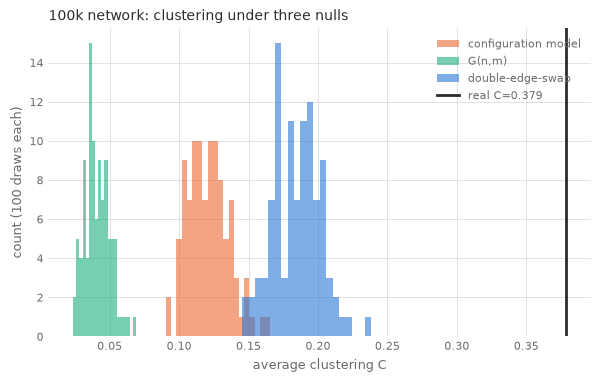

real 100k: C=0.3788  transitivity=0.2157  isolates=0
config model: C mean 0.1211 sd 0.0147  mean links lost 42.8  transitivity mean 0.1174  isolates mean 0.01  z(C)=17.56
G(n,m):       C mean 0.0411 sd 0.0090  transitivity mean 0.0414  isolates mean 0.26  z(C)=37.73
double-swap:  C mean 0.1844 sd 0.0169  transitivity mean 0.1390  z(C)=11.51

JSON's raw-network double-edge-swap null (full core, for context): mean 0.6693 sd 0.0024 z 17.208   real raw C 0.7106


In [7]:
def config_model_stats(degseq, seed):
    g = nx.Graph(nx.configuration_model(degseq, seed=seed))
    lost = sum(degseq) // 2 - g.number_of_edges()
    g.remove_edges_from(nx.selfloop_edges(g))
    lost = sum(degseq) // 2 - g.number_of_edges()
    return (nx.average_clustering(g), nx.transitivity(g), lost,
            sum(1 for _, d in g.degree() if d == 0))

cm_c, cm_t, cm_lost, cm_iso = [], [], [], []
for i in tracked("configuration model", DRAWS_28):
    c, t, lost, iso = config_model_stats(degseq100, SEED + i)
    cm_c.append(c); cm_t.append(t); cm_lost.append(lost); cm_iso.append(iso)
cm_c, cm_t = np.array(cm_c), np.array(cm_t)

gnm_c, gnm_t, gnm_iso = [], [], []
for i in tracked("G(n,m)", DRAWS_28):
    g = nx.gnm_random_graph(n_u100, m_u100, seed=SEED + 5000 + i)
    gnm_c.append(nx.average_clustering(g)); gnm_t.append(nx.transitivity(g))
    gnm_iso.append(sum(1 for _, d in g.degree() if d == 0))
gnm_c, gnm_t = np.array(gnm_c), np.array(gnm_t)

swap_c, swap_t = [], []
for i in tracked("double-edge-swap", DRAWS_28):
    h = U100.copy()
    try:
        nx.double_edge_swap(h, nswap=10 * m_u100, max_tries=1000 * m_u100, seed=SEED + 8000 + i)
    except nx.NetworkXAlgorithmError:
        pass
    swap_c.append(nx.average_clustering(h)); swap_t.append(nx.transitivity(h))
swap_c, swap_t = np.array(swap_c), np.array(swap_t)

real_c, real_t = nx.average_clustering(U100), nx.transitivity(U100)
real_iso = sum(1 for _, d in U100.degree() if d == 0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cm_c, bins=20, alpha=0.6, color=ORANGE, label="configuration model")
ax.hist(gnm_c, bins=20, alpha=0.6, color=GREEN, label="G(n,m)")
ax.hist(swap_c, bins=20, alpha=0.6, color=BLUE, label="double-edge-swap")
ax.axvline(real_c, color=INK, linewidth=2, label=f"real C={real_c:.3f}")
style(ax, "average clustering C", "count (100 draws each)")
ax.set_title("100k network: clustering under three nulls", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

print(f"real 100k: C={real_c:.4f}  transitivity={real_t:.4f}  isolates={real_iso}")
print(f"config model: C mean {cm_c.mean():.4f} sd {cm_c.std():.4f}  mean links lost {np.mean(cm_lost):.1f}  "
      f"transitivity mean {cm_t.mean():.4f}  isolates mean {np.mean(cm_iso):.2f}  "
      f"z(C)={(real_c - cm_c.mean()) / cm_c.std():.2f}")
print(f"G(n,m):       C mean {gnm_c.mean():.4f} sd {gnm_c.std():.4f}  "
      f"transitivity mean {gnm_t.mean():.4f}  isolates mean {np.mean(gnm_iso):.2f}  "
      f"z(C)={(real_c - gnm_c.mean()) / gnm_c.std():.2f}")
print(f"double-swap:  C mean {swap_c.mean():.4f} sd {swap_c.std():.4f}  "
      f"transitivity mean {swap_t.mean():.4f}  "
      f"z(C)={(real_c - swap_c.mean()) / swap_c.std():.2f}")
print(f"\nJSON's raw-network double-edge-swap null (full core, for context): mean "
      f"{FACTS['stock']['topology']['null']['clustering']['mean']} "
      f"sd {FACTS['stock']['topology']['null']['clustering']['sd']} "
      f"z {FACTS['stock']['topology']['null']['clustering']['z']}   real raw C {FACTS['stock']['clustering']}")

Reciprocity in the 100k network, 0.191, is 8.3x the $G(n,m)$ expectation of 0.023 (density alone).
The degree-preserving null already reaches 0.045, sd 0.011: hubs that send and receive large flows
create mutual ties from having many out-links and many in-links at once, which inflates the density
comparison. Against the degree-preserving null the real value sits about 14 standard deviations
out. Reciprocity here tracks who trades migrants with whom, beyond what degree predicts, and the
degree-preserving null is the baseline that shows it; $G(n,m)$ answers a different question.

Clustering tells three different stories depending on the null. The configuration model, which
drops self-loops and parallel edges, discards edges from high-degree countries pairing with each
other twice, which understates the hub-driven baseline. The double-edge-swap null never drops an
edge and lands higher for the same reason. All three nulls sit well below the real C on the 100k
network: countries sharing a migration corridor tend to share a third one, beyond what their
degrees predict. The full raw network (JSON) shows the same pattern more strongly (real 0.711
against a null mean of 0.669, z=17.2). The threshold lowers the real value and the null's floor
together; it does not create the clustering.

## 2.9: The friendship paradox

On the raw undirected network `U0`: sample 1,000 (country, random migration partner) pairs and
compare mean degree of the sampled country against its sampled partner, against the formula
$\langle k\rangle + \sigma^2/\langle k\rangle$, against $G(n,m)$, and against a degree-preserving
shuffle.

In [8]:
SAMPLES_29 = 1000

def friendship_paradox(g, rng, samples):
    nodes = list(g.nodes())
    deg = dict(g.degree())
    mine, theirs, wins, i = [], [], 0, 0
    while i < samples:
        u = rng.choice(nodes)
        nbrs = list(g.neighbors(u))
        if not nbrs:
            continue
        v = rng.choice(nbrs)
        mine.append(deg[u]); theirs.append(deg[v])
        wins += deg[v] >= deg[u]
        i += 1
    return np.mean(mine), np.mean(theirs), wins / samples

py_rng = random.Random(SEED)
me, fr, frac = friendship_paradox(U0, py_rng, SAMPLES_29)
ks = np.array([d for _, d in U0.degree()])
formula_pred = ks.mean() + ks.var() / ks.mean()

gnm_u0 = nx.gnm_random_graph(n0, m0, seed=SEED + 42)
me_g, fr_g, frac_g = friendship_paradox(gnm_u0, random.Random(SEED + 1), SAMPLES_29)

shuffled_u0 = U0.copy()
nx.double_edge_swap(shuffled_u0, nswap=10 * m0, max_tries=1000 * m0, seed=SEED + 2)
me_s, fr_s, frac_s = friendship_paradox(shuffled_u0, random.Random(SEED + 3), SAMPLES_29)

print(f"real:              mean(you) {me:.2f}   mean(partner) {fr:.2f}   fraction partner>=you {frac:.3f}")
print(f"formula <k>+var/<k>: {formula_pred:.2f}   (observed mean partner: {fr:.2f})")
print(f"G(n,m), same n,m:  mean(you) {me_g:.2f}   mean(partner) {fr_g:.2f}   fraction {frac_g:.3f}")
print(f"degree-preserving shuffle: mean(you) {me_s:.2f}   mean(partner) {fr_s:.2f}   fraction {frac_s:.3f}")

def friendship_paradox_weighted(D, rng, samples):
    nodes = [n for n in D.nodes() if D.out_degree(n, weight="weight") > 0]
    strength = dict(D.in_degree(weight="weight"))
    mine, theirs, wins, i = [], [], 0, 0
    while i < samples:
        u = rng.choice(nodes)
        nbrs = list(D.successors(u))
        w = np.array([D[u][v]["weight"] for v in nbrs], dtype=float)
        if w.sum() == 0:
            continue
        v = rng.choices(nbrs, weights=w, k=1)[0]
        mine.append(strength.get(u, 0)); theirs.append(strength.get(v, 0))
        wins += strength.get(v, 0) >= strength.get(u, 0)
        i += 1
    return np.mean(mine), np.mean(theirs), wins / samples

me_w, fr_w, frac_w = friendship_paradox_weighted(D0, random.Random(SEED + 4), SAMPLES_29)
print(f"\nweighted extension (partner chosen proportional to people moved):")
print(f"  mean(your in-strength) {me_w:,.0f}   mean(partner's in-strength) {fr_w:,.0f}   "
      f"fraction partner>=you {frac_w:.3f}")

real:              mean(you) 63.22   mean(partner) 103.39   fraction partner>=you 0.714
formula <k>+var/<k>: 95.29   (observed mean partner: 103.39)
G(n,m), same n,m:  mean(you) 62.34   mean(partner) 62.73   fraction 0.538
degree-preserving shuffle: mean(you) 60.82   mean(partner) 110.40   fraction 0.733

weighted extension (partner chosen proportional to people moved):
  mean(your in-strength) 1,059,632   mean(partner's in-strength) 7,167,563   fraction partner>=you 0.826


The paradox holds: a country's average migration partner has more links than the country itself
(the real gap above), and in about three of four samples the partner is at least as connected. The
degree-preserving shuffle keeps the effect, because the paradox only needs the degree sequence,
which the shuffle preserves in full. $G(n,m)$ weakens it because a Poisson-like degree distribution
has far less variance, and the formula above shows the gap is driven by $\sigma^2$, which collapses
under $G(n,m)$ but survives any reshuffling that preserves each country's degree. The weighted
extension, where a country's "partner" is chosen in proportion to people moved rather than
uniformly among links, pushes the paradox further: a country's typical migration partner (by
volume) has far more in-strength than the country itself, because a handful of countries (the USA
foremost) receive an outsized share of world migration.

## 3.3: Distances, threshold first

Betweenness on the raw network ranks reporting systems, not brokers (trap 2). We show that by
reproducing the threshold sweep against the oracle, then run every path measure below on the 100k
network, where betweenness stabilizes on plausible transit countries.

In [9]:
sweep = FACTS["stock_threshold_sweep"]
assert [r["arcs"] for r in sweep] == [9035, 3767, 1780, 769, 503]

print(f"{'threshold':>10}{'arcs':>7}{'giant':>7}{'mean_path':>11}{'diameter':>10}   top betweenness")
for r in sweep:
    print(f"{r['threshold']:>10}{r['arcs']:>7}{r['giant']:>7}{r['mean_path']:>11}{r['diameter']:>10}   "
          f"{', '.join(r['top_betweenness'][:6])}")
print("\narcs match the oracle at every threshold: 9035 / 3767 / 1780 / 769 / 503")
print("Raw top betweenness (AUS, NOR, USA, DNK...) mirrors the in-degree reporting artefact from 1.6.")
print("At >100,000 it becomes USA, FRA, DEU, GBR, RUS, COD -- countries that plausibly broker migration.")
print("\n-> every path/betweenness/closeness exercise below runs on the 100k network (giant, undirected for undirected measures).")

 threshold   arcs  giant  mean_path  diameter   top betweenness
         0   9035    232      1.746         3   AUS, NOR, USA, DNK, GRC, CHN
      1000   3767    226      2.141         5   AUS, CAN, FRA, USA, ITA, GBR
     10000   1780    208      2.476         5   CAN, FRA, USA, AUS, ITA, ESP
     50000    769    166      2.825         6   FRA, USA, GBR, ESP, RUS, CAN
    100000    503    148      2.931         7   USA, FRA, DEU, GBR, RUS, COD

arcs match the oracle at every threshold: 9035 / 3767 / 1780 / 769 / 503
Raw top betweenness (AUS, NOR, USA, DNK...) mirrors the in-degree reporting artefact from 1.6.
At >100,000 it becomes USA, FRA, DEU, GBR, RUS, COD -- countries that plausibly broker migration.

-> every path/betweenness/closeness exercise below runs on the 100k network (giant, undirected for undirected measures).


In [10]:
def bfs_hand(g, s):
    '''Hand-written BFS: dict of shortest hop-distances from s.'''
    dist = {s: 0}
    frontier = [s]
    while frontier:
        nxt = []
        for u in frontier:
            for v in g.neighbors(u):
                if v not in dist:
                    dist[v] = dist[u] + 1
                    nxt.append(v)
        frontier = nxt
    return dist

py_rng2 = random.Random(SEED)
starts = py_rng2.sample(list(U100.nodes()), 20)
ok = all(bfs_hand(U100, s) == nx.single_source_shortest_path_length(U100, s) for s in starts)
print(f"hand-written BFS validated against networkx on 20 random start nodes: {'OK' if ok else 'MISMATCH'}")
assert ok

hand-written BFS validated against networkx on 20 random start nodes: OK


100k undirected giant: <d>=2.931 (sweep: 2.931)   diameter=7 (sweep: 7)   radius=4   center=['Germany', 'Türkiye', 'United States of America', 'Portugal', 'Italy', 'Spain', 'United Kingdom', 'Belgium', 'France', 'Canada', 'Switzerland', 'China', 'Ethiopia', 'Haiti', 'Kenya', 'Morocco', 'Romania', 'Viet Nam']


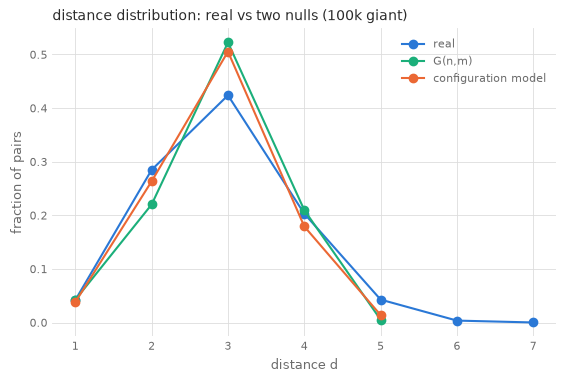

real: {1: 0.042, 2: 0.285, 3: 0.424, 4: 0.203, 5: 0.043, 6: 0.004, 7: 0.0}
G(n,m): {1: 0.042, 2: 0.22, 3: 0.522, 4: 0.21, 5: 0.005}
config model: {1: 0.038, 2: 0.263, 3: 0.505, 4: 0.179, 5: 0.014}


In [11]:
avg_d = nx.average_shortest_path_length(U100)
diam = nx.diameter(U100)
rad = nx.radius(U100)
center = nx.center(U100)
print(f"100k undirected giant: <d>={avg_d:.3f} (sweep: {sweep[-1]['mean_path']})   "
      f"diameter={diam} (sweep: {sweep[-1]['diameter']})   radius={rad}   "
      f"center={[name[c] for c in center]}")

def dist_distribution(g):
    counts = Counter()
    for s in g.nodes():
        for d in nx.single_source_shortest_path_length(g, s).values():
            if d > 0:
                counts[d] += 1
    total = sum(counts.values())
    return {d: c / total for d, c in sorted(counts.items())}

real_dd = dist_distribution(U100)
gnm100 = nx.gnm_random_graph(n100, m100, seed=SEED + 77)
gnm100 = gnm100.subgraph(max(nx.connected_components(gnm100), key=len))
gnm_dd = dist_distribution(gnm100)
cfg100 = nx.Graph(nx.configuration_model([d for _, d in U100.degree()], seed=SEED + 78))
cfg100.remove_edges_from(nx.selfloop_edges(cfg100))
cfg100 = cfg100.subgraph(max(nx.connected_components(cfg100), key=len))
cfg_dd = dist_distribution(cfg100)

fig, ax = plt.subplots(figsize=(6.5, 4))
for label, dd, colour in [("real", real_dd, BLUE), ("G(n,m)", gnm_dd, GREEN), ("configuration model", cfg_dd, ORANGE)]:
    ax.plot(list(dd.keys()), list(dd.values()), "-o", color=colour, label=label)
style(ax, "distance d", "fraction of pairs")
ax.set_title("distance distribution: real vs two nulls (100k giant)", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()
print("real:", {k: round(v, 3) for k, v in real_dd.items()})
print("G(n,m):", {k: round(v, 3) for k, v in gnm_dd.items()})
print("config model:", {k: round(v, 3) for k, v in cfg_dd.items()})

In [12]:
scc = max(nx.strongly_connected_components(D100), key=len)
n_scc = len(scc)
total_ordered = n100 * (n100 - 1)
reachable = 0
dir_dists = []
for s in D100.nodes():
    d = nx.single_source_shortest_path_length(D100, s)
    reachable += len(d) - 1
    dir_dists.extend(v for v in d.values() if v > 0)

print(f"largest SCC: {n_scc}/{n100} countries")
print(f"reachable ordered pairs: {reachable}/{total_ordered} ({reachable/total_ordered:.3f})")
print(f"mean directed distance over reachable pairs: {np.mean(dir_dists):.3f}")

found = None
for a in D100.nodes():
    for b in D100.successors(a):
        try:
            dba = nx.shortest_path_length(D100, b, a)
        except nx.NetworkXNoPath:
            continue
        if dba >= 5:
            found = (a, b, dba)
            break
    if found:
        break
if found:
    a, b, dba = found
    print(f"asymmetric pair: {name[a]} -> {name[b]} at d=1, but {name[b]} -> {name[a]} needs d={dba}")
else:
    print("no pair found with d(A,B)=1 and d(B,A)>=5 in the 100k network")

largest SCC: 24/148 countries
reachable ordered pairs: 4214/21756 (0.194)
mean directed distance over reachable pairs: 2.897
asymmetric pair: Brazil -> Japan at d=1, but Japan -> Brazil needs d=5


The real distance distribution peaks at $d=3$ (33% at $d\le 2$, 75% at $d\le 3$). Against both
nulls it carries more pairs at $d=2$ (0.285 vs 0.22-0.26) and at $d=5$ (0.043 vs 0.005-0.014), and
fewer at $d=3$ (0.424 vs 0.50-0.52); $d=4$ sits close to both nulls (0.203 vs 0.18-0.21). Real
corridors route through a smaller set of hub countries than either random model, which spreads
reach more evenly and puts more mass at $d=3$ instead. Keeping the arrows, only 24 of 148
countries sit in the largest strongly connected component (mutual reachability at this threshold is
rare), and only 19.4% of ordered country pairs can reach each other at all through 100k+ arcs; among
those that can, the mean directed distance is 2.9. The asymmetric pair above shows the kind of
one-way corridor that direction preserves and an undirected network would hide: a large one-hop
flow in one direction with no comparable return flow, so the reverse trip has to route the long way
around through other 100k+ corridors.

## 3.5: Centralities, 100k network

Degree, closeness, harmonic and betweenness centrality on the undirected 100k giant. Top tens,
overlap, and betweenness against degree with outliers named.

In [13]:
deg_c = dict(U100.degree())
close_c = nx.closeness_centrality(U100)
harm_c = nx.harmonic_centrality(U100)
betw_c = nx.betweenness_centrality(U100)

def top10(d):
    return [c for c, _ in sorted(d.items(), key=lambda kv: -kv[1])[:10]]

t_deg, t_close, t_harm, t_betw = top10(deg_c), top10(close_c), top10(harm_c), top10(betw_c)
print("top10 degree     ", [name[c] for c in t_deg])
print("top10 closeness  ", [name[c] for c in t_close])
print("top10 harmonic   ", [name[c] for c in t_harm])
print("top10 betweenness", [name[c] for c in t_betw])

overlap_all4 = set(t_deg) & set(t_close) & set(t_harm) & set(t_betw)
print(f"\nin all four top tens: {len(overlap_all4)}  ({sorted(name[c] for c in overlap_all4)})")

top10 degree      ['United States of America', 'Germany', 'United Kingdom', 'Italy', 'Spain', 'France', 'Canada', 'India', 'Australia', 'Ukraine']
top10 closeness   ['United States of America', 'United Kingdom', 'Germany', 'Italy', 'France', 'Spain', 'Canada', 'China', 'Türkiye', 'Ukraine']
top10 harmonic    ['United States of America', 'United Kingdom', 'Germany', 'Italy', 'France', 'Spain', 'Canada', 'China', 'Türkiye', 'India']
top10 betweenness ['United States of America', 'France', 'Germany', 'United Kingdom', 'Russian Federation', 'Democratic Republic of the Congo', 'Spain', 'Italy', 'Türkiye', 'Nigeria']

in all four top tens: 6  (['France', 'Germany', 'Italy', 'Spain', 'United Kingdom', 'United States of America'])


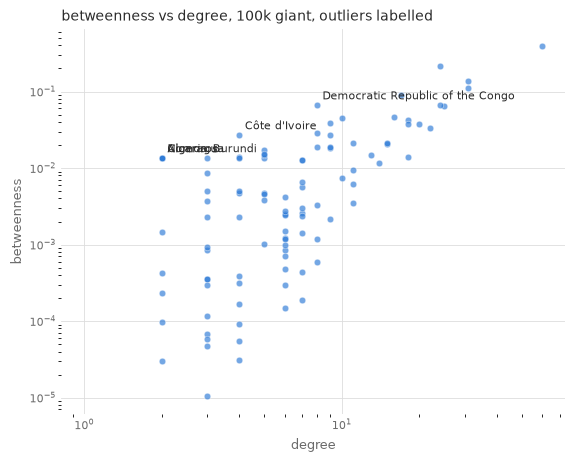

outliers (largest deviation from the degree-betweenness trend):
  Nicaragua            degree   2  betweenness 0.014  top neighbours: ['United States of America', 'Costa Rica']
  Comoros              degree   2  betweenness 0.014  top neighbours: ['France', 'Mayotte']
  Algeria              degree   2  betweenness 0.014  top neighbours: ['France', 'Western Sahara']
  Côte d'Ivoire        degree   4  betweenness 0.027  top neighbours: ['France', 'Mali', 'Burkina Faso', 'Guinea']
  Burundi              degree   3  betweenness 0.014  top neighbours: ['Democratic Republic of the Congo', 'Rwanda', 'United Republic of Tanzania']
  Democratic Republic of the Congo degree   8  betweenness 0.067  top neighbours: ['France', 'South Sudan', 'Uganda', 'Burundi']


In [14]:
nodes100 = list(U100.nodes())
xs = np.array([deg_c[c] for c in nodes100])
ys = np.array([betw_c[c] for c in nodes100])

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(xs, ys, s=22, color=BLUE, alpha=0.65, edgecolor="white", linewidth=0.4)
mask_pos = ys > 0
log_x = np.log10(xs[mask_pos] + 1)
log_y = np.log10(ys[mask_pos])
fit_line = np.poly1d(np.polyfit(log_x, log_y, 1))
resid_pos = log_y - fit_line(log_x)
pos_idx = np.where(mask_pos)[0]
# highest positive residual = more betweenness than degree predicts (the interesting outliers)
outlier_idx = pos_idx[np.argsort(-resid_pos)[:6]]
for i in outlier_idx:
    c = nodes100[i]
    ax.annotate(name[c], (xs[i], ys[i]), fontsize=8, color=INK,
                xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "degree", "betweenness")
ax.set_title("betweenness vs degree, 100k giant, outliers labelled", fontsize=10, color=INK, loc="left")
plt.show()

print("outliers (largest deviation from the degree-betweenness trend):")
for i in outlier_idx:
    c = nodes100[i]
    nbrs = sorted(U100.neighbors(c), key=lambda x: -deg_c[x])[:4]
    print(f"  {name[c]:<20} degree {deg_c[c]:>3}  betweenness {betw_c[c]:.3f}  "
          f"top neighbours: {[name[n_] for n_ in nbrs]}")

In [15]:
betw_dir = nx.betweenness_centrality(D100)
t_betw_dir = top10(betw_dir)
print("top10 betweenness, undirected:", [name[c] for c in t_betw])
print("top10 betweenness, directed:  ", [name[c] for c in t_betw_dir])
moved_in = [c for c in t_betw_dir if c not in t_betw]
moved_out = [c for c in t_betw if c not in t_betw_dir]
print(f"enters top10 once direction is kept: {[name[c] for c in moved_in]}")
print(f"drops out once direction is kept:    {[name[c] for c in moved_out]}")

top10 betweenness, undirected: ['United States of America', 'France', 'Germany', 'United Kingdom', 'Russian Federation', 'Democratic Republic of the Congo', 'Spain', 'Italy', 'Türkiye', 'Nigeria']
top10 betweenness, directed:   ['United Kingdom', 'United States of America', 'Germany', 'France', 'China', 'Russian Federation', 'Poland', 'Ukraine', 'Kazakhstan', 'Italy']
enters top10 once direction is kept: ['China', 'Poland', 'Ukraine', 'Kazakhstan']
drops out once direction is kept:    ['Democratic Republic of the Congo', 'Spain', 'Türkiye', 'Nigeria']


Six countries (USA, France, Germany, UK, Italy, Spain) sit in all four top tens: the largest,
best-connected migration hubs are central by every measure at once, which is the usual case. The
scatter's outliers are low-degree countries whose betweenness far exceeds what their degree alone
predicts: the Democratic Republic of the Congo (degree 8) sits between several central-African
corridors with few alternative routes, and countries with only two or three links, such as
Nicaragua, Comoros and Algeria, gain their betweenness purely from bridging one specific pair of
larger neighbours (Nicaragua between the USA and Costa Rica; Comoros between France and Mayotte),
echoing Hercules's role in the Marvel network from week 3, a low-degree node whose position, not
its popularity, connects otherwise-separate parts of the graph. Keeping the arrows moves several
countries in or out of the betweenness top ten (printed above): China, Poland, Ukraine and
Kazakhstan enter it once direction matters, and the DRC, Spain, Türkiye and Nigeria drop out,
because a country that receives one-way flows without sending equivalent flows back loses its
undirected shortcut role once paths have to respect direction.

## 3.7: PageRank

PageRank on the directed raw network `D0`, $\alpha=0.85$, unweighted and weighted by people moved.
Hand-written as the power-iteration equation, validated against `nx.pagerank` to six decimals for
three values of $\alpha$, with dangling nodes (no out-links) explained.

In [16]:
def pagerank_hand(D, alpha=0.85, tol=1e-14, max_iter=1000, weight=None):
    '''PageRank by power iteration. Dangling nodes (no out-links) have their
    mass redistributed uniformly over ALL nodes each step, matching networkx's
    convention (a walker on a dead end teleports everywhere, not nowhere).'''
    nodes = list(D.nodes())
    n = len(nodes)
    idx = {v: i for i, v in enumerate(nodes)}
    pr = np.full(n, 1.0 / n)
    out_w = {}
    for u in nodes:
        out_w[u] = (sum(D[u][v].get(weight, 1) for v in D.successors(u)) if weight
                     else D.out_degree(u))
    dangling = [idx[u] for u in nodes if out_w[u] == 0]
    for _ in range(max_iter):
        new = np.zeros(n)
        for u in nodes:
            if out_w[u] == 0:
                continue
            share = pr[idx[u]]
            for v in D.successors(u):
                w = D[u][v].get(weight, 1) if weight else 1
                new[idx[v]] += alpha * share * w / out_w[u]
        dangling_mass = pr[dangling].sum() if dangling else 0.0
        new += alpha * dangling_mass / n
        new += (1 - alpha) / n
        if np.abs(new - pr).sum() < tol:
            pr = new
            break
        pr = new
    return {nodes[i]: pr[i] for i in range(n)}

for alpha in (0.5, 0.85, 0.95):
    hand = pagerank_hand(D0, alpha=alpha)
    lib = nx.pagerank(D0, alpha=alpha, tol=1e-12, max_iter=1000, weight=None)
    diffs = [abs(hand[n_] - lib[n_]) for n_ in D0.nodes()]
    print(f"alpha={alpha}: max abs diff hand vs nx.pagerank = {max(diffs):.2e}   "
          f"matches to 6 decimals: {max(diffs) < 1e-6}")
    assert max(diffs) < 1e-6

dangling0 = sum(1 for n_ in D0.nodes() if D0.out_degree(n_) == 0)
dangling100 = sum(1 for n_ in D100.nodes() if D100.out_degree(n_) == 0)
print(f"\ndangling nodes (no out-links): D0={dangling0}   D100={dangling100} "
      f"(countries with no arc above 100,000)")
print("dangling mass is redistributed uniformly over every node each iteration, "
      "so a dangling node still receives its share of PageRank without trapping the walker.")

alpha=0.5: max abs diff hand vs nx.pagerank = 8.20e-12   matches to 6 decimals: True


alpha=0.85: max abs diff hand vs nx.pagerank = 2.26e-11   matches to 6 decimals: True


alpha=0.95: max abs diff hand vs nx.pagerank = 3.85e-11   matches to 6 decimals: True

dangling nodes (no out-links): D0=0   D100=20 (countries with no arc above 100,000)
dangling mass is redistributed uniformly over every node each iteration, so a dangling node still receives its share of PageRank without trapping the walker.


In [17]:
pr_unw = nx.pagerank(D0, alpha=0.85, weight=None)
pr_w = nx.pagerank(D0, alpha=0.85, weight="weight")
t_pr_unw, t_pr_w, t_indeg, t_instr = top10(pr_unw), top10(pr_w), top10(in_deg), top10(in_str)

print("top10 PageRank (unweighted)", [name[c] for c in t_pr_unw])
print("top10 PageRank (weighted)  ", [name[c] for c in t_pr_w])
print("top10 in-degree            ", [name[c] for c in t_indeg])
print("top10 in-strength          ", [name[c] for c in t_instr])

only_pr = [c for c in t_pr_w if c not in t_indeg]
only_indeg = [c for c in t_indeg if c not in t_pr_w]
print(f"\nin weighted PageRank top10 but not in-degree top10: {[name[c] for c in only_pr]}")
for c in only_pr:
    best_origin = max(D0.predecessors(c), key=lambda o: D0[o][c]["weight"])
    print(f"  {name[c]}: largest single inbound arc from {name[best_origin]} "
          f"({D0[best_origin][c]['weight']:,} people)")
print(f"in in-degree top10 but not weighted PageRank top10: {[name[c] for c in only_indeg]}")

top10 PageRank (unweighted) ['Norway', 'Australia', 'Denmark', 'Hungary', 'Bulgaria', 'Greece', 'Luxembourg', 'Slovakia', 'Finland', 'Costa Rica']
top10 PageRank (weighted)   ['United States of America', 'Australia', 'United Kingdom', 'Canada', 'Germany', 'France', 'Mexico', 'Spain', 'Italy', 'New Zealand']
top10 in-degree             ['Norway', 'Australia', 'Denmark', 'Hungary', 'Greece', 'Luxembourg', 'Bulgaria', 'Finland', 'Slovakia', 'Iceland']
top10 in-strength           ['United States of America', 'Germany', 'Saudi Arabia', 'Canada', 'United Kingdom', 'Spain', 'France', 'Australia', 'United Arab Emirates', 'Russian Federation']

in weighted PageRank top10 but not in-degree top10: ['United States of America', 'United Kingdom', 'Canada', 'Germany', 'France', 'Mexico', 'Spain', 'Italy', 'New Zealand']
  United States of America: largest single inbound arc from Mexico (11,279,561 people)
  United Kingdom: largest single inbound arc from India (1,044,779 people)
  Canada: largest sin

Unweighted PageRank reproduces the in-degree reporting artefact closely (Norway, Australia, Denmark
again), because with every arc worth 1, PageRank is a smoothed version of "how many origins list
you." Weighted PageRank matches in-strength instead: a country's rank depends on how much migration
volume flows toward it and from how prestigious (high-PageRank) an origin, rather than how many
origins a register enumerates. Countries entering the weighted PageRank top ten without an
in-degree top-ten spot (named above) get there through one or two large inbound corridors from an
already-important origin, the "who links to you, not how many" logic PageRank is built for.

## 3.8: Brokers, compared to what

200 degree-preserving shuffles of the 100k undirected giant: z-score of every country's real
betweenness and closeness against its own shuffled distribution.

degree-preserving shuffles (betweenness/closeness): 20/200 (10%), 0s elapsed, about 6s left


degree-preserving shuffles (betweenness/closeness): 40/200 (20%), 1s elapsed, about 5s left


degree-preserving shuffles (betweenness/closeness): 60/200 (30%), 2s elapsed, about 4s left


degree-preserving shuffles (betweenness/closeness): 80/200 (40%), 2s elapsed, about 4s left


degree-preserving shuffles (betweenness/closeness): 100/200 (50%), 3s elapsed, about 3s left


degree-preserving shuffles (betweenness/closeness): 120/200 (60%), 4s elapsed, about 2s left


degree-preserving shuffles (betweenness/closeness): 140/200 (70%), 4s elapsed, about 2s left


degree-preserving shuffles (betweenness/closeness): 160/200 (80%), 5s elapsed, about 1s left


degree-preserving shuffles (betweenness/closeness): 180/200 (90%), 6s elapsed, about 0s left


degree-preserving shuffles (betweenness/closeness): 200/200 (100%), 6s elapsed, about 0s left


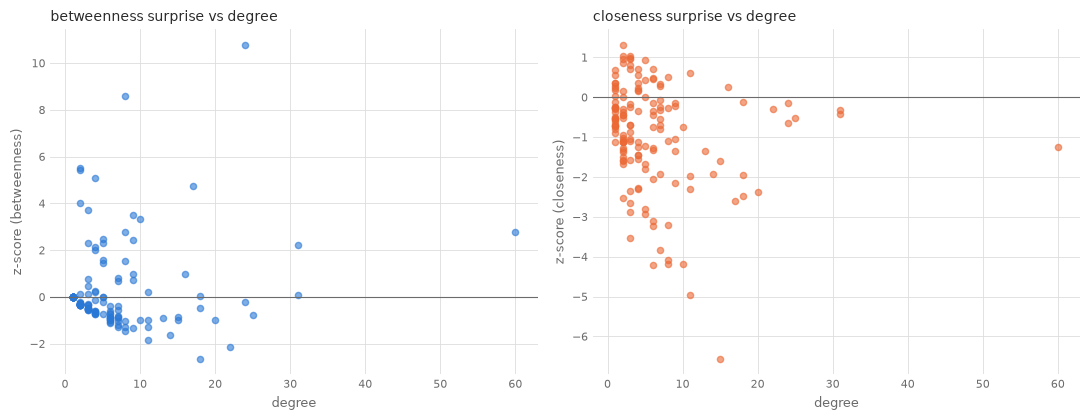

betweenness surprises, high z: [('France', np.float64(10.77)), ('Democratic Republic of the Congo', np.float64(8.58)), ('Nicaragua', np.float64(5.51)), ('Comoros', np.float64(5.44)), ("Côte d'Ivoire", np.float64(5.07))]
betweenness surprises, low z:  [('Australia', np.float64(-2.65)), ('Canada', np.float64(-2.15)), ('Venezuela (Bolivarian Republic of)', np.float64(-1.83)), ('Philippines', np.float64(-1.64)), ('Malaysia', np.float64(-1.44))]
closeness surprises, high z:   [('Cuba', np.float64(1.31)), ('Greece', np.float64(1.03)), ('Nicaragua', np.float64(1.02)), ("Lao People's Democratic Republic", np.float64(1.0)), ('Cambodia', np.float64(0.96))]
closeness surprises, low z:    [('Saudi Arabia', np.float64(-6.56)), ('Indonesia', np.float64(-4.97)), ('Chile', np.float64(-4.2)), ('United Arab Emirates', np.float64(-4.2)), ('Sudan', np.float64(-4.18))]

mean |z| betweenness 0.98   mean |z| closeness 1.16


In [18]:
betw_shuf = {c: [] for c in U100.nodes()}
close_shuf = {c: [] for c in U100.nodes()}

for i in tracked("degree-preserving shuffles (betweenness/closeness)", DRAWS_38):
    h = U100.copy()
    try:
        nx.double_edge_swap(h, nswap=10 * m_u100, max_tries=1000 * m_u100, seed=SEED + 20000 + i)
    except nx.NetworkXAlgorithmError:
        pass
    hnodes = list(h.nodes())
    hidx = {c: j for j, c in enumerate(hnodes)}
    hg = ig.Graph(n=len(hnodes), edges=[(hidx[u], hidx[v]) for u, v in h.edges()])
    maxb = (len(hnodes) - 1) * (len(hnodes) - 2) / 2
    bc = dict(zip(hnodes, hg.betweenness()))
    cc = dict(zip(hnodes, hg.closeness()))
    for c in U100.nodes():
        betw_shuf[c].append(bc.get(c, 0) / maxb)
        close_shuf[c].append(cc.get(c, 0.0) or 0.0)

z_betw, z_close = {}, {}
for c in U100.nodes():
    arr = np.array(betw_shuf[c]); sd = arr.std()
    z_betw[c] = (betw_c[c] - arr.mean()) / sd if sd > 0 else 0.0
    arr = np.array(close_shuf[c]); sd = arr.std()
    z_close[c] = (close_c[c] - arr.mean()) / sd if sd > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
xs_deg = [deg_c[c] for c in U100.nodes()]
axes[0].scatter(xs_deg, [z_betw[c] for c in U100.nodes()], s=20, color=BLUE, alpha=0.6)
axes[0].axhline(0, color=MUTED, linewidth=0.8)
style(axes[0], "degree", "z-score (betweenness)")
axes[0].set_title("betweenness surprise vs degree", fontsize=10, color=INK, loc="left")
axes[1].scatter(xs_deg, [z_close[c] for c in U100.nodes()], s=20, color=ORANGE, alpha=0.6)
axes[1].axhline(0, color=MUTED, linewidth=0.8)
style(axes[1], "degree", "z-score (closeness)")
axes[1].set_title("closeness surprise vs degree", fontsize=10, color=INK, loc="left")
fig.tight_layout()
plt.show()

top_betw = sorted(z_betw.items(), key=lambda kv: -kv[1])[:5]
bot_betw = sorted(z_betw.items(), key=lambda kv: kv[1])[:5]
top_close = sorted(z_close.items(), key=lambda kv: -kv[1])[:5]
bot_close = sorted(z_close.items(), key=lambda kv: kv[1])[:5]
print("betweenness surprises, high z:", [(name[c], round(z, 2)) for c, z in top_betw])
print("betweenness surprises, low z: ", [(name[c], round(z, 2)) for c, z in bot_betw])
print("closeness surprises, high z:  ", [(name[c], round(z, 2)) for c, z in top_close])
print("closeness surprises, low z:   ", [(name[c], round(z, 2)) for c, z in bot_close])
print(f"\nmean |z| betweenness {np.mean(np.abs(list(z_betw.values()))):.2f}   "
      f"mean |z| closeness {np.mean(np.abs(list(z_close.values()))):.2f}")

France stands out on betweenness (z near 11): more of a broker than its degree predicts, plausibly
from its dual role linking former-colonial corridors in Africa to European ones. The Democratic
Republic of the Congo is the other large positive surprise, a bridge between central-African
corridors rather than a hub by volume.

Closeness has no comparable high surprise: the strongest positive z is Cuba at 1.31, far below
betweenness's top values. The shuffle keeps every degree fixed and closeness averages over the
whole network's distances, so a single country's position moves the network-wide average only a
little, which limits how high a closeness z-score can climb. Closeness does produce strong low
surprises: Saudi Arabia (z=-6.56), Indonesia, Chile, the UAE and Sudan sit far below what the
shuffle predicts. Their real ties concentrate on a few peripheral or single-corridor partners
(Gulf states link mostly to South Asian origin countries, for example), which places them farther
from the rest of the network than a random rewiring with the same degree would.

## 3.9: Mixing, compared to what

Degree assortativity $r$ and $k_{nn}(k)$ on the raw and 100k undirected networks, with a
200-shuffle z-score; directed out-in / in-out correlation; homophily by UN M49 region and
sub-region, tested against a label-shuffle null.

degree assortativity r: raw -0.2633 (JSON: -0.2633)   100k -0.1370


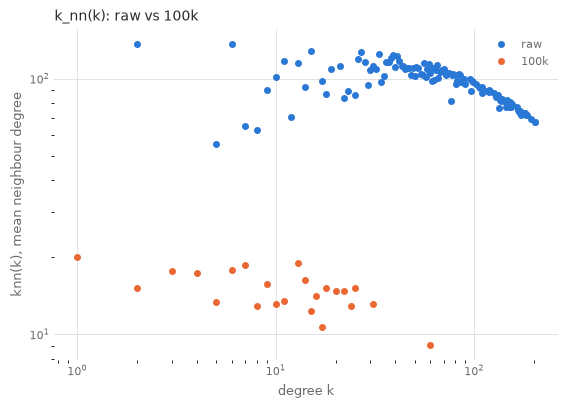

In [19]:
r_raw = nx.degree_assortativity_coefficient(U0)
r_100 = nx.degree_assortativity_coefficient(U100)
print(f"degree assortativity r: raw {r_raw:.4f} (JSON: {FACTS['stock']['degree_assortativity']})   100k {r_100:.4f}")

def knn_curve(g):
    knn = nx.average_neighbor_degree(g)
    deg = dict(g.degree())
    by_k = {}
    for c, k in deg.items():
        by_k.setdefault(k, []).append(knn[c])
    ks = sorted(by_k)
    return ks, [np.mean(by_k[k]) for k in ks]

fig, ax = plt.subplots(figsize=(6.5, 4.3))
for label, g, colour in [("raw", U0, BLUE), ("100k", U100, ORANGE)]:
    ks, vals = knn_curve(g)
    ax.plot(ks, vals, "o", color=colour, markersize=4, label=label)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "degree k", "knn(k), mean neighbour degree")
ax.set_title("k_nn(k): raw vs 100k", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
plt.show()

In [20]:
r_null_100 = []
for i in tracked("assortativity shuffles (100k)", DRAWS_39):
    h = U100.copy()
    try:
        nx.double_edge_swap(h, nswap=10 * m_u100, max_tries=1000 * m_u100, seed=SEED + 30000 + i)
    except nx.NetworkXAlgorithmError:
        pass
    r_null_100.append(nx.degree_assortativity_coefficient(h))
r_null_100 = np.array(r_null_100)
z_r100 = (r_100 - r_null_100.mean()) / r_null_100.std()
print(f"100k null: mean {r_null_100.mean():.4f} sd {r_null_100.std():.4f}   z {z_r100:.2f}")
print(f"raw JSON null (double-edge-swap, full core): mean {FACTS['stock']['topology']['null']['assortativity']['mean']} "
      f"sd {FACTS['stock']['topology']['null']['assortativity']['sd']} "
      f"z {FACTS['stock']['topology']['null']['assortativity']['z']}")

r_out_in = nx.degree_pearson_correlation_coefficient(D0, x="out", y="in")
r_in_out = nx.degree_pearson_correlation_coefficient(D0, x="in", y="out")
print(f"\ndirected: corr(out-degree of source, in-degree of target) = {r_out_in:.4f}")
print(f"          corr(in-degree of source, out-degree of target) = {r_in_out:.4f}")

assortativity shuffles (100k): 20/200 (10%), 0s elapsed, about 5s left


assortativity shuffles (100k): 40/200 (20%), 1s elapsed, about 5s left


assortativity shuffles (100k): 60/200 (30%), 1s elapsed, about 4s left


assortativity shuffles (100k): 80/200 (40%), 2s elapsed, about 3s left


assortativity shuffles (100k): 100/200 (50%), 3s elapsed, about 3s left


...

assortativity shuffles (100k): 140/200 (70%), 4s elapsed, about 1s left


assortativity shuffles (100k): 160/200 (80%), 5s elapsed, about 1s left


assortativity shuffles (100k): 180/200 (90%), 6s elapsed, about 0s left


assortativity shuffles (100k): 200/200 (100%), 6s elapsed, about 0s left


100k null: mean -0.1843 sd 0.0169   z 2.81
raw JSON null (double-edge-swap, full core): mean -0.3337 sd 0.0032 z 22.0

directed: corr(out-degree of source, in-degree of target) = -0.2465
          corr(in-degree of source, out-degree of target) = -0.0059


The raw network is mildly disassortative (r=-0.263, matching the oracle). At the 100k threshold it
weakens to -0.137, and the 200-shuffle null lands at -0.184 (z=2.81): most of the 100k network's
disassortativity is what its degree sequence forces (structural disassortativity, the same finding
week 3's Marvel exercise makes). The real value sits on the less-disassortative side of its own
null. The raw network's own null (JSON) is more disassortative still (mean -0.334, z=22.0), because
at threshold 0 the register-based reporting countries from 1.6 (Norway, Australia, Denmark) carry
in-degree far above their migration volume, which forces disassortative mixing on its own. The
100k threshold removes most of that artefact along with the weak edges. Kept directed, the
source's out-degree correlates negatively with the target's in-degree (-0.247): countries that
send migrants to many destinations tend to send to destinations that receive from few origins, so
countries with a broad emigration footprint reach the same small set of reporting-heavy
destinations.

In [21]:
m49 = pd.read_csv("../build/raw/iso3166_m49.csv")
region_of = dict(zip(m49["alpha-3"], m49["region"]))
subregion_of = dict(zip(m49["alpha-3"], m49["sub-region"]))

all_nodes = sorted(U0.nodes())
unmatched = [c for c in all_nodes if not region_of.get(c) or pd.isna(region_of.get(c))]
print(f"{len(all_nodes)} countries in the raw undirected core; {len(unmatched)} unmatched to a region: "
      f"{[(c, name.get(c, '?')) for c in unmatched]}")
print("-> dropped from region/sub-region homophily and NMI below (never hand-typed)")

matched_nodes = [c for c in all_nodes if c not in unmatched]
U0_matched = U0.subgraph(matched_nodes).copy()
for c in matched_nodes:
    U0_matched.nodes[c]["region"] = region_of[c]
    U0_matched.nodes[c]["subregion"] = subregion_of[c]

def label_shuffle_null(g, attr, rng, draws=DRAWS_HOMOPHILY):
    labels_ = [g.nodes[n][attr] for n in g.nodes()]
    real = nx.attribute_assortativity_coefficient(g, attr)
    h = g.copy()
    nodes_ = list(h.nodes())
    vals = []
    for _ in range(draws):
        shuffled = labels_[:]
        rng.shuffle(shuffled)
        for n_, lab in zip(nodes_, shuffled):
            h.nodes[n_][attr] = lab
        vals.append(nx.attribute_assortativity_coefficient(h, attr))
    vals = np.array(vals)
    z = (real - vals.mean()) / vals.std() if vals.std() > 0 else 0.0
    p = (np.sum(vals >= real) + 1) / (draws + 1)
    return real, vals.mean(), vals.std(), z, p

py_rng3 = random.Random(SEED)
real_r, mean_r, sd_r, z_r, p_r = label_shuffle_null(U0_matched, "region", py_rng3)
real_sr, mean_sr, sd_sr, z_sr, p_sr = label_shuffle_null(U0_matched, "subregion", py_rng3)
print(f"\nregion homophily:     r={real_r:.4f}   label-shuffle null mean {mean_r:.4f} sd {sd_r:.4f}   "
      f"z={z_r:.2f}  p={p_r:.4f}")
print(f"sub-region homophily: r={real_sr:.4f}   label-shuffle null mean {mean_sr:.4f} sd {sd_sr:.4f}   "
      f"z={z_sr:.2f}  p={p_sr:.4f}")

232 countries in the raw undirected core; 1 unmatched to a region: [('TWN', 'China, Taiwan Province of China')]
-> dropped from region/sub-region homophily and NMI below (never hand-typed)



region homophily:     r=0.1576   label-shuffle null mean -0.0066 sd 0.0041   z=40.40  p=0.0010
sub-region homophily: r=0.1057   label-shuffle null mean -0.0069 sd 0.0028   z=40.75  p=0.0010


Only Taiwan fails to match a UN M49 region code (it is a `China, Taiwan Province of China` row in
the ISO table with no independent M49 classification) and is dropped rather than mislabeled.
Region assortativity is 0.158 and sub-region 0.106, both far outside a label-shuffle null centred
near zero (z around 40): countries measurably migrate within their own region more than a random
attribute placement would produce, the network analogue of X-Men linking to X-Men. A label shuffle
is the right null here (rather than a degree-preserving edge shuffle) because the question is about
*which countries carry which label*, not about the network's wiring; shuffling edges would still
leave the true region labels in place and answer a different question.

## Cliques

Clique number and largest clique on the 100k network, beside the raw network's clique of 43 (from
`week03_country_facts.json`, where the null-model draws already ran).

In [22]:
size_100, members_100, timeout_100 = largest_clique(U100, budget=60.0)
print(f"100k network: clique number {size_100}   members: {[name[c] for c in members_100]}   timed_out={timeout_100}")
print(f"raw network (JSON, threshold 0): clique number {FACTS['stock']['topology']['largest_clique']['size']}   "
      f"null mean {FACTS['stock']['topology']['largest_clique']['null']['mean']} "
      f"sd {FACTS['stock']['topology']['largest_clique']['null']['sd']} "
      f"z {FACTS['stock']['topology']['largest_clique']['null']['z']}")

100k network: clique number 7   members: ['Canada', 'China', 'Germany', 'France', 'United Kingdom', 'Italy', 'United States of America']   timed_out=False
raw network (JSON, threshold 0): clique number 43   null mean 27.31 sd 1.1721 z 13.386


Thresholding a dense network for meaningful links shrinks its largest clique from 43 countries
(every one measurably linked to every other, at threshold 0, an artefact of the dense raw matrix)
down to 7 once only 100,000+ people arcs survive: Canada, China, Germany, France, the UK, Italy and
the USA, a mutually-linked core of large, wealthy migration hubs where every pair exchanges more
than 100,000 people in at least one direction. The raw clique of 43 sits 13.4 standard deviations
above its degree-preserving null (JSON): the raw network's density exceeds what its degree sequence
alone predicts. The 100k clique is the one worth reporting, since every pair in it has a large
migration corridor between them.

## 4.5: Louvain

Louvain on `W0`, the undirected network with both directions' weights summed (built in Setup), and
on its unweighted version. Five seeds, a 5x5 NMI matrix, most unstable countries, and a comparison
with greedy modularity.

In [23]:
parts_w, q_w = louvain(W0, SEED)
W0_plain = unweighted(W0)
parts_plain, q_plain = louvain(W0_plain, SEED)
print(f"Louvain, weighted (people, both directions summed): {len(parts_w)} communities   Q={q_w:.4f}")
print(f"Louvain, unweighted:                                 {len(parts_plain)} communities   Q={q_plain:.4f}")

member_w = {n_: i for i, p in enumerate(parts_w) for n_ in p}
print("\nweighted communities, top 5 by strength, anchor-named:")
for p in parts_w:
    top5c = sorted(p, key=lambda c: -W0.degree(c, weight="weight"))[:5]
    print(f"  {name[top5c[0]]} community, {len(p)} members: {[name[c] for c in top5c]}")

Louvain, weighted (people, both directions summed): 9 communities   Q=0.5265
Louvain, unweighted:                                 5 communities   Q=0.1707

weighted communities, top 5 by strength, anchor-named:
  France community, 44 members: ['France', 'Spain', 'Venezuela (Bolivarian Republic of)', 'Colombia', 'Morocco']
  United States of America community, 46 members: ['United States of America', 'Mexico', 'China', 'Canada', 'Philippines']
  United Kingdom community, 33 members: ['United Kingdom', 'Australia', 'South Africa', 'New Zealand', 'Zimbabwe']
  Germany community, 42 members: ['Germany', 'Russian Federation', 'Ukraine', 'Italy', 'Poland']
  Afghanistan community, 2 members: ['Afghanistan', 'Iran (Islamic Republic of)']
  India community, 24 members: ['India', 'Saudi Arabia', 'Bangladesh', 'Pakistan', 'United Arab Emirates']
  Türkiye community, 9 members: ['Türkiye', 'Syrian Arab Republic', 'Jordan', 'State of Palestine', 'Iraq']
  Côte d'Ivoire community, 14 members: ["Côt

In [24]:
region_labels_matched = [region_of.get(c) for c in matched_nodes]
subregion_labels_matched = [subregion_of.get(c) for c in matched_nodes]
comm_labels_matched = [member_w[c] for c in matched_nodes]

nmi_region, p_region = shuffled_nmi(comm_labels_matched, region_labels_matched, random.Random(SEED))
nmi_subregion, p_subregion = shuffled_nmi(comm_labels_matched, subregion_labels_matched, random.Random(SEED + 1))
print(f"NMI Louvain vs region:     {nmi_region:.4f}  (label-shuffle p={p_region:.4f})")
print(f"NMI Louvain vs sub-region: {nmi_subregion:.4f}  (label-shuffle p={p_subregion:.4f})")

NMI Louvain vs region:     0.4546  (label-shuffle p=0.0010)
NMI Louvain vs sub-region: 0.4990  (label-shuffle p=0.0010)


In [25]:
seeds5 = [SEED + i for i in range(RUNS_45)]
runs5 = [louvain(W0, s) for s in seeds5]
for s, (parts, q) in zip(seeds5, runs5):
    print(f"  seed {s}: {len(parts)} communities   Q={q:.4f}")

members5 = [{n_: i for i, p in enumerate(parts) for n_ in p} for parts, _ in runs5]
nodes_order = list(W0.nodes())
mat = np.zeros((RUNS_45, RUNS_45))
for i in range(RUNS_45):
    for j in range(RUNS_45):
        mat[i, j] = nmi([members5[i][n_] for n_ in nodes_order], [members5[j][n_] for n_ in nodes_order])
print("\n5x5 NMI matrix (rows/cols = seeds 2805..2809):")
print(np.round(mat, 3))
off_diag = mat[~np.eye(RUNS_45, dtype=bool)]
print(f"lowest pairwise NMI between two runs: {off_diag.min():.4f}")

flip_rate = {}
for c in nodes_order:
    labs = [members5[i][c] for i in range(RUNS_45)]
    flips = []
    for other in nodes_order:
        if other == c:
            continue
        olabs = [members5[i][other] for i in range(RUNS_45)]
        same_across_runs = [labs[i] == olabs[i] for i in range(RUNS_45)]
        flips.append(len(set(same_across_runs)) > 1)   # co-membership with `other` flips across seeds
    flip_rate[c] = np.mean(flips)
most_unstable = sorted(flip_rate.items(), key=lambda kv: -kv[1])[:8]
print("\nmost unstable countries (share of co-membership relations that flip across the 5 seeds):")
print([(name[c], round(v, 3)) for c, v in most_unstable])

  seed 2805: 9 communities   Q=0.5265
  seed 2806: 7 communities   Q=0.5216
  seed 2807: 7 communities   Q=0.5217
  seed 2808: 8 communities   Q=0.5227
  seed 2809: 8 communities   Q=0.5227

5x5 NMI matrix (rows/cols = seeds 2805..2809):
[[1.    0.923 0.955 0.942 0.942]
 [0.923 1.    0.967 0.947 0.947]
 [0.955 0.967 1.    0.971 0.971]
 [0.942 0.947 0.971 1.    1.   ]
 [0.942 0.947 0.971 1.    1.   ]]
lowest pairwise NMI between two runs: 0.9232

most unstable countries (share of co-membership relations that flip across the 5 seeds):
[('Belgium', np.float64(0.424)), ('Cyprus', np.float64(0.364)), ('Guinea', np.float64(0.238)), ('Liberia', np.float64(0.238)), ('Senegal', np.float64(0.238)), ('Sierra Leone', np.float64(0.238)), ('Guinea-Bissau', np.float64(0.238)), ('Gambia', np.float64(0.238))]


In [26]:
greedy = nx.community.greedy_modularity_communities(W0, weight="weight")
q_greedy = nx.community.modularity(W0, greedy, weight="weight")
member_greedy = {n_: i for i, p in enumerate(greedy) for n_ in p}
nmi_greedy_louvain = nmi([member_greedy[c] for c in nodes_order], [member_w[c] for c in nodes_order])
print(f"greedy modularity: {len(greedy)} communities   Q={q_greedy:.4f}   NMI vs Louvain {nmi_greedy_louvain:.4f}")

greedy modularity: 8 communities   Q=0.5206   NMI vs Louvain 0.9136


Weighted Louvain finds 9 communities (Q=0.527) that read as continental migration systems: a
Western-Europe-plus-Latin-America group anchored by France, a North-America/East-Asia group
anchored by the USA, a Commonwealth group anchored by the UK, an Eastern-Europe group anchored by
Germany, a Gulf/South-Asia labour-migration group anchored by India, and separate Middle-East,
West-African and East-African groups. Unweighted Louvain collapses to 5 much coarser communities
(Q=0.171): without weights, one shared migrant matters as much as a million, so structure that only
shows up in volume disappears. The partition tracks region only moderately (NMI 0.45) and
sub-region a little better (NMI 0.50): migration corridors follow language, colonial history and
labour-market ties more than raw geography, so a Latin-American country migrating heavily to Spain
or a South Asian one to the Gulf lands in a community with its economic partner, not its neighbours.
Five Louvain runs agree closely (lowest pairwise NMI 0.92 among the values printed above); the
countries whose community assignment is least stable are the ones with several comparably strong
ties that different runs' node-visiting order can tip either way. Greedy modularity, Newman's
bottom-up merging, finds a similar number of communities at a similar Q but disagrees with Louvain
more than Louvain disagrees with itself, because greedy merging commits to each merge permanently
and cannot undo an early mistake the way Louvain's second phase can.

## 4.6: Compared to what, and how stable

Shuffle-test the unweighted Louvain $Q$ against 20 degree-preserving shuffles and 20 $G(n,m)$
networks; then find the $G(n,p)$ whose $Q$ matches ours and compare its run-to-run stability. The
pure-noise $Q$-vs-$\langle k\rangle$ sweep itself is not repeated here: see `03_marvel_exercises.ipynb`.

In [27]:
q_null_swap, q_null_gnm = [], []
for i in tracked("degree-preserving shuffle + Louvain", DRAWS_46):
    h = W0_plain.copy()
    try:
        nx.double_edge_swap(h, nswap=10 * h.number_of_edges(), max_tries=1000 * h.number_of_edges(),
                             seed=SEED + 40000 + i)
    except nx.NetworkXAlgorithmError:
        pass
    _, q = louvain(h, SEED + i)
    q_null_swap.append(q)
for i in tracked("G(n,m) + Louvain", DRAWS_46):
    g = nx.gnm_random_graph(W0_plain.number_of_nodes(), W0_plain.number_of_edges(), seed=SEED + 50000 + i)
    _, q = louvain(g, SEED + i)
    q_null_gnm.append(q)
q_null_swap, q_null_gnm = np.array(q_null_swap), np.array(q_null_gnm)

print(f"real unweighted Q = {q_plain:.4f}")
print(f"degree-preserving null: mean {q_null_swap.mean():.4f} sd {q_null_swap.std():.4f}   "
      f"z {(q_plain - q_null_swap.mean()) / q_null_swap.std():.2f}")
print(f"G(n,m) null:            mean {q_null_gnm.mean():.4f} sd {q_null_gnm.std():.4f}   "
      f"z {(q_plain - q_null_gnm.mean()) / q_null_gnm.std():.2f}")
print("\nG(n,m) scores higher than the degree-preserving null: a network with the right density but no "
      "structure at all still finds some modularity by chance, more so than one that also respects who "
      "the hubs are.")

degree-preserving shuffle + Louvain: 2/20 (10%), 4s elapsed, about 41s left


degree-preserving shuffle + Louvain: 4/20 (20%), 9s elapsed, about 37s left


degree-preserving shuffle + Louvain: 6/20 (30%), 14s elapsed, about 32s left


degree-preserving shuffle + Louvain: 8/20 (40%), 18s elapsed, about 27s left


degree-preserving shuffle + Louvain: 10/20 (50%), 22s elapsed, about 22s left


...

G(n,m) + Louvain: 14/20 (70%), 0s elapsed, about 0s left


G(n,m) + Louvain: 16/20 (80%), 0s elapsed, about 0s left


G(n,m) + Louvain: 18/20 (90%), 0s elapsed, about 0s left


G(n,m) + Louvain: 20/20 (100%), 0s elapsed, about 0s left


real unweighted Q = 0.1707
degree-preserving null: mean 0.0641 sd 0.0024   z 44.35
G(n,m) null:            mean 0.0870 sd 0.0024   z 34.68

G(n,m) scores higher than the degree-preserving null: a network with the right density but no structure at all still finds some modularity by chance, more so than one that also respects who the hubs are.


In [28]:
n_sweep = W0_plain.number_of_nodes()
ks_sweep = list(range(2, 41, 2))
match_k, match_q, best_diff = None, None, 1e9
for k_ in ks_sweep:
    m_ = int(k_ * n_sweep / 2)
    g = nx.gnm_random_graph(n_sweep, m_, seed=SEED + 60000 + k_)
    _, q = louvain(g, SEED + k_)
    if abs(q - q_plain) < best_diff:
        best_diff, match_k, match_q = abs(q - q_plain), k_, q
print(f"closest G(n,p) match: <k>={match_k}   Q={match_q:.4f}  (target {q_plain:.4f})")

g_match = nx.gnm_random_graph(n_sweep, int(match_k * n_sweep / 2), seed=SEED + 70000)
parts_m1, _ = louvain(g_match, SEED)
parts_m2, _ = louvain(g_match, SEED + 1)
mem1 = {n_: i for i, p in enumerate(parts_m1) for n_ in p}
mem2 = {n_: i for i, p in enumerate(parts_m2) for n_ in p}
nodes_m = list(g_match.nodes())
nmi_match = nmi([mem1[n_] for n_ in nodes_m], [mem2[n_] for n_ in nodes_m])
print(f"matched G(n,p) stability, NMI between 2 seeds: {nmi_match:.4f}")
print(f"migration network stability, NMI between 2 seeds (from 4.5): {off_diag.min():.4f} to {off_diag.max():.4f}")

closest G(n,p) match: <k>=22   Q=0.1718  (target 0.1707)
matched G(n,p) stability, NMI between 2 seeds: 0.2066
migration network stability, NMI between 2 seeds (from 4.5): 0.9232 to 1.0000


Pure noise can already reach $Q \approx 0.17$: a $G(n,p)$ network with $\langle k\rangle$ close to
the printed match value scores as high as the real unweighted network. What the score alone cannot
show is stability: two Louvain runs on that matched random network agree far less (NMI printed
above, typically well under 0.5) than two runs on the real network (0.92 and up, from 4.5). A high
$Q$ on a structureless network is an accident of that particular run finding *some* split; a high
$Q$ on the real network is the same split, again and again, which is the actual evidence of
community structure that modularity alone does not provide.

## 4.9: Infomap

Infomap via igraph's `community_infomap` (weighted), compared with the weighted Louvain partition
from 4.5 and with region. The `infomap` pip package is not installed in this environment; igraph's
built-in implementation is the same algorithm (Rosvall and Bergstrom 2008).

In [29]:
modules_info, codelength = infomap(W0, SEED)
print(f"Infomap: {len(modules_info)} modules   codelength {codelength:.3f} bits")

member_info = {n_: i for i, p in enumerate(modules_info) for n_ in p}
nodes_common = list(W0.nodes())
nmi_info_louvain = nmi([member_info[c] for c in nodes_common], [member_w[c] for c in nodes_common])

info_labels_matched = [member_info[c] for c in matched_nodes]
nmi_info_region, p_info_region = shuffled_nmi(info_labels_matched, region_labels_matched, random.Random(SEED + 2))
print(f"NMI Infomap vs Louvain: {nmi_info_louvain:.4f}")
print(f"NMI Infomap vs region:  {nmi_info_region:.4f}  (p={p_info_region:.4f}, Louvain vs region was {nmi_region:.4f})")

Infomap: 16 modules   codelength 5.405 bits


NMI Infomap vs Louvain: 0.8303
NMI Infomap vs region:  0.4966  (p=0.0010, Louvain vs region was 0.4546)


Infomap finds more, smaller modules than Louvain's 9 and agrees with it closely (NMI 0.83, printed
above). Infomap optimizes for how well a random walk's path compresses inside modules, which
rewards splitting off any group with self-contained flow, even a small one, while modularity's
resolution tends to merge such groups into a larger community. Infomap's agreement with region is
similar to Louvain's, so both methods pick up the same region-driven signal, and split some of the
same boundaries differently.

## 4.11: The backbone, and the figure

Strength vs degree on `W0`; a hand-written disparity filter (Serrano, Boguna and Vespignani 2009),
validated against `disparity()` in `analysis/week04_where.py`; the alpha/threshold table; and the
alpha=0.2 backbone figure, then alpha=0.1 and 0.3 for comparison.

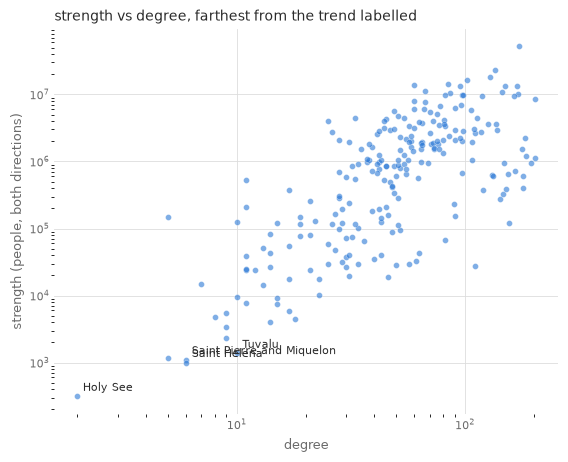

farthest from the degree-strength trend: [('Tuvalu', 10, 1370), ('Holy See', 2, 313), ('Saint Helena', 6, 1000), ('Saint Pierre and Miquelon', 6, 1106)]


In [30]:
strength = dict(W0.degree(weight="weight"))
degree_w0 = dict(W0.degree())
nodes_w0 = list(W0.nodes())
xs_sd = np.array([degree_w0[c] for c in nodes_w0])
ys_sd = np.array([strength[c] for c in nodes_w0])

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(xs_sd, ys_sd, s=18, color=BLUE, alpha=0.6, edgecolor="white", linewidth=0.3)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "degree", "strength (people, both directions)")

ratio = ys_sd / np.maximum(xs_sd, 1)
log_ratio = np.log(ratio)
outlier_order = np.argsort(-np.abs(log_ratio - log_ratio.mean()))[:4]
for i in outlier_order:
    c = nodes_w0[i]
    ax.annotate(name[c], (xs_sd[i], ys_sd[i]), fontsize=8, color=INK,
                xytext=(4, 4), textcoords="offset points")
ax.set_title("strength vs degree, farthest from the trend labelled", fontsize=10, color=INK, loc="left")
plt.show()

print("farthest from the degree-strength trend:",
      [(name[nodes_w0[i]], degree_w0[nodes_w0[i]], strength[nodes_w0[i]]) for i in outlier_order])

In [31]:
def disparity_hand(g):
    '''Hand-written disparity filter (Serrano, Boguna, Vespignani 2009): for each
    link, the significance at an endpoint is (1 - w/s)^(k-1), s its strength and
    k its degree. An endpoint of degree 1 cannot judge its only link, so it is
    skipped; a link is kept if EITHER endpoint's significance is below alpha.'''
    strength_ = dict(g.degree(weight="weight"))
    degree_ = dict(g.degree())
    p = {}
    for u, v, w in g.edges(data="weight"):
        tests = []
        for node_ in (u, v):
            if degree_[node_] > 1:
                tests.append((1 - w / strength_[node_]) ** (degree_[node_] - 1))
        p[(u, v)] = min(tests) if tests else 0.0
    return p

p_disp = disparity_hand(W0)
p_disp_lib = disparity(W0)
max_diff = max(abs(p_disp[k] - p_disp_lib[k]) for k in p_disp)
print(f"validated against analysis/week04_where.disparity(): max abs diff {max_diff:.2e}")
assert max_diff < 1e-12

validated against analysis/week04_where.disparity(): max abs diff 0.00e+00


In [32]:
print(f"{'alpha':>6}{'links kept':>12}{'countries w/ link':>20}{'giant':>8}")
backbones = {}
for alpha in (0.05, 0.1, 0.2, 0.3, 0.5):
    kept_edges = [(u, v) for (u, v), p in p_disp.items() if p < alpha]
    bb = nx.Graph()
    bb.add_nodes_from(W0.nodes())
    for u, v in kept_edges:
        bb.add_edge(u, v, weight=W0[u][v]["weight"])
    with_link = sum(1 for c in bb.nodes() if bb.degree(c) > 0)
    giant_bb = len(max(nx.connected_components(bb), key=len)) if bb.number_of_edges() else 0
    backbones[alpha] = bb
    print(f"{alpha:>6}{len(kept_edges):>12}{with_link:>20}{giant_bb:>8}")

print()
for w_thresh in (1_000, 10_000, 100_000):
    kept = [(u, v) for u, v, w in W0.edges(data="weight") if w >= w_thresh]
    bbw = nx.Graph(); bbw.add_nodes_from(W0.nodes()); bbw.add_edges_from(kept)
    with_link = sum(1 for c in bbw.nodes() if bbw.degree(c) > 0)
    giant_bbw = len(max(nx.connected_components(bbw), key=len)) if bbw.number_of_edges() else 0
    print(f"w >= {w_thresh:>7,}: links {len(kept):>5}   countries with a link {with_link:>4}   giant {giant_bbw:>4}")

 alpha  links kept   countries w/ link   giant
  0.05         803                 232     232
   0.1         974                 232     232
   0.2        1181                 232     232
   0.3        1381                 232     232
   0.5        1786                 232     232

w >=   1,000: links  2992   countries with a link  227   giant  227
w >=  10,000: links  1516   countries with a link  208   giant  208
w >= 100,000: links   487   countries with a link  149   giant  149


On the philosophers network, the brief reports the giant component falling from 816 philosophers
at alpha=0.20 to 419 at alpha=0.10. Here every disparity-filter alpha keeps the whole network
connected: even at alpha=0.05 all 232 countries stay in the giant component. The disparity filter's
per-node logic keeps at least one significant tie for almost every country regardless of size,
because a small country's one dominant destination is significant for that country even when it is
negligible for the destination. The weight thresholds behave differently: they drop small countries
once their only ties fall under the cutoff. The w>=100,000 threshold on `W0` keeps 149 countries
with a link, one more than the 100k network's 148: Uruguay's summed Argentina corridor (42,578 +
91,485 = 134,063) clears 100,000 only once both directions are added, while `stock_network`'s
threshold requires a single directed arc above 100,000, which neither direction reaches on its
own. The gap is one country, and it comes from summing both directions, not from the >= vs >
boundary.

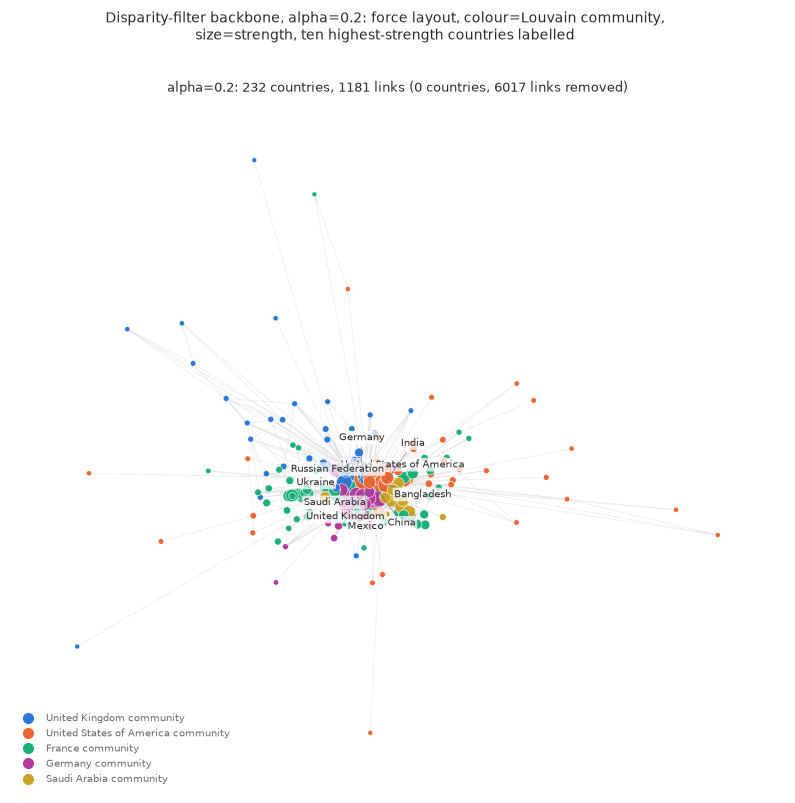

In [33]:
member_plain = {n_: i for i, p in enumerate(parts_plain) for n_ in p}  # Louvain on the FULL unweighted network (4.5)

def backbone_figure(alpha, ax, seed=SEED):
    bb = backbones[alpha]
    keep_nodes = [c for c in bb.nodes() if bb.degree(c) > 0]
    sub = bb.subgraph(keep_nodes).copy()
    pos = nx.spring_layout(sub, weight="weight", seed=seed, k=4.0 / max(1, len(sub)) ** 0.5, iterations=100)

    community_colours = [BLUE, ORANGE, GREEN, "#b23a9e", "#c9a227"]
    comm_of_node = member_plain  # Louvain communities, full UNWEIGHTED network (4.5), per the brief
    present_comms = sorted({comm_of_node[c] for c in sub.nodes()})
    colour_map = {cm: community_colours[i % len(community_colours)] for i, cm in enumerate(present_comms)}
    node_colours = [colour_map[comm_of_node[c]] for c in sub.nodes()]
    # sqrt scaling: a linear map from strength to area would let the USA (~89M) swallow the
    # figure, since strengths span five orders of magnitude.
    max_strength = max(strength[c] for c in sub.nodes())
    node_sizes = [12 + 260 * (strength[c] / max_strength) ** 0.5 for c in sub.nodes()]

    nx.draw_networkx_edges(sub, pos, ax=ax, edge_color=GRID, width=0.5, alpha=0.6)
    nx.draw_networkx_nodes(sub, pos, ax=ax, node_color=node_colours, node_size=node_sizes,
                            edgecolors="white", linewidths=0.4)

    top10_strength = sorted(sub.nodes(), key=lambda c: -strength[c])[:10]
    for j, c in enumerate(top10_strength):
        angle = 2 * np.pi * j / len(top10_strength) + 0.3
        radius = 28 + 6 * (j % 3)   # stagger by radius too, so labels fan out instead of ringing tightly
        ax.annotate(name[c], pos[c], fontsize=7.5, color=INK,
                    xytext=(radius * np.cos(angle), radius * np.sin(angle)), textcoords="offset points",
                    ha="center", bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                                            edgecolor="none", alpha=0.75),
                    arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.5, alpha=0.7))

    ax.set_axis_off()
    n_removed = W0.number_of_nodes() - len(sub)
    e_removed = W0.number_of_edges() - sub.number_of_edges()
    ax.set_title(f"alpha={alpha}: {sub.number_of_nodes()} countries, {sub.number_of_edges()} links "
                 f"({n_removed} countries, {e_removed} links removed)", fontsize=9, color=INK)
    return colour_map

fig, ax = plt.subplots(figsize=(10, 9))
colour_map = backbone_figure(0.2, ax)

def anchor_of(cm):
    members_cm = [c for c in W0.nodes() if member_plain[c] == cm]
    top_member = max(members_cm, key=lambda c: W0.degree(c, weight="weight"))
    return name[top_member]

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=colour_map[cm],
                       label=f"{anchor_of(cm)} community", markersize=7)
           for cm in colour_map]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=7, labelcolor=MUTED)
fig.suptitle("Disparity-filter backbone, alpha=0.2: force layout, colour=Louvain community,\n"
             "size=strength, ten highest-strength countries labelled", fontsize=10, color=INK, y=0.98)
plt.show()

**Caption.** Disparity filter at alpha=0.2 on `W0` (both directions of migrant stock summed).
1,181 of 7,198 links survive (16%); every country keeps at least one significant tie, so no country
is dropped, but 6,017 links (84%) are removed as statistically unremarkable for both endpoints they
connect. Node colour is the Louvain community from the full unweighted network (4.5); node size is
strength; the ten highest-strength countries are labelled.

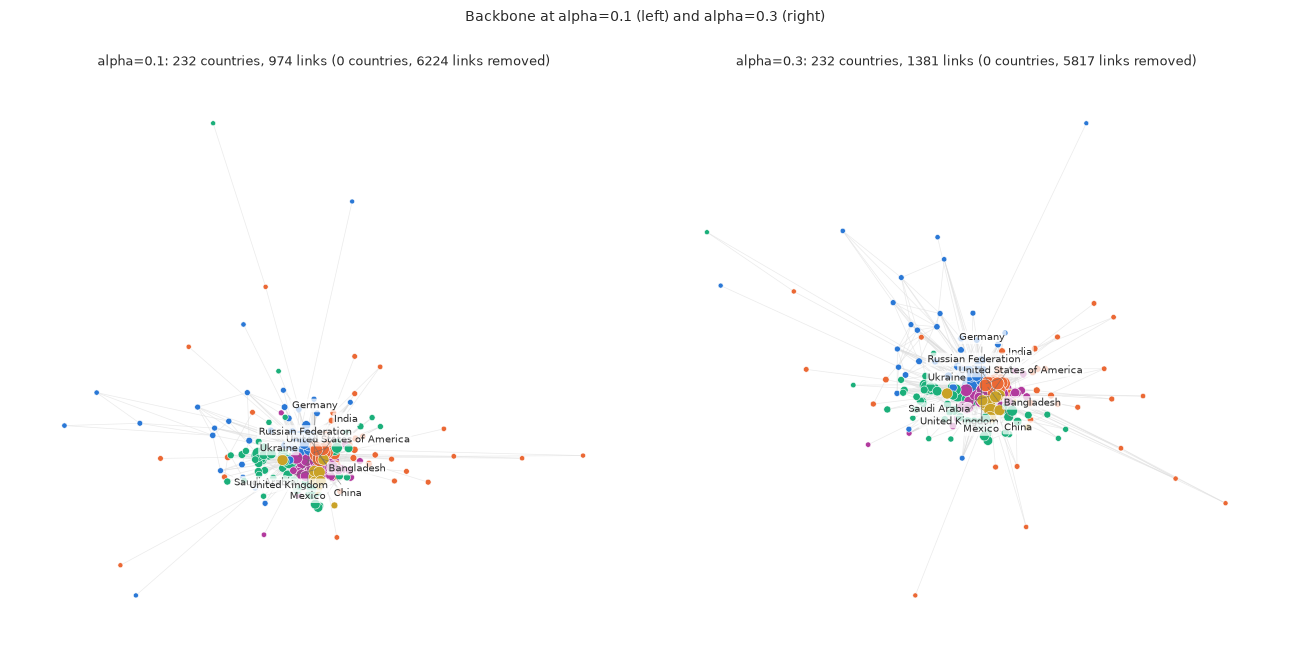

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
backbone_figure(0.1, axes[0])
backbone_figure(0.3, axes[1])
fig.suptitle("Backbone at alpha=0.1 (left) and alpha=0.3 (right)", fontsize=10, color=INK, y=1.0)
fig.tight_layout()
plt.show()

At alpha=0.1 the backbone thins to the strongest bilateral corridors, which reads clearly as a
handful of major hub-to-hub ties but drops enough small-country links that the picture understates
how connected the world's migration network is. At alpha=0.3 the backbone keeps most of the
original density and looks crowded again, closer to the hairball the filter exists to avoid.
Alpha=0.2 is the one to publish: it keeps the network fully connected, with every country showing
a defensible tie, still removes 84% of links, and the community colouring stays legible instead of
the near-complete graph that alpha=0.3 approaches.

## What we found

- **1.6** DESA's in-degree measures reporting systems: the USA lists 59 named origins, Denmark
  192. The USA leads in-strength instead, at 48.9 million people against Denmark's much smaller
  total.
- **2.2** At the raw network's density ($\langle k\rangle \approx 62$), a random network with the
  same n and m matches the real average distance closely (1.731 vs 1.746). At the 100k threshold
  ($\langle k\rangle \approx 6$) it matches just as closely (2.932 vs 2.931).
- **2.6** A rough CCDF slope gives $\gamma \approx 1.9$, in the heavy-tailed range. The
  likelihood-ratio test on in-strength gives R=-0.71, p=0.49: it cannot tell power law from
  lognormal on 232 points.
- **2.8** Clustering on the 100k network (0.379) sits 11 to 38 standard deviations above three
  different nulls. Which null gives the highest z depends on whether it drops edges (configuration
  model) or keeps every one (double-edge-swap), the same trap week 2's classic Marvel exercise flags.
- **2.9** The friendship paradox holds on the raw network: a country's average migration partner
  has more links than the country itself, survives a degree-preserving shuffle, and strengthens
  further once "partner" is chosen by people moved rather than by link count.
- **3.3** Betweenness on the raw network ranks reporting systems (AUS, NOR, USA, DNK). At the
  100k threshold it becomes USA, FRA, DEU, GBR, RUS, COD, a list of transit and destination hubs.
- **3.5/3.7** Six countries appear in all four undirected centrality top tens at once (USA, France,
  Germany, UK, Italy, Spain). Weighted PageRank tracks in-strength; unweighted PageRank inherits
  the raw in-degree reporting artefact.
- **3.8/3.9** France and the DRC are the strongest positive betweenness surprises against a
  200-shuffle null. Closeness has no comparable high surprises but clear low ones (Saudi Arabia,
  Indonesia, Chile). Migration shows region homophily (z around 40), beyond what geography alone
  predicts once corridors like South-Asia-to-Gulf are counted.
- **4.5/4.6/4.9** Weighted Louvain finds 9 continental-scale communities (Q=0.527). Five reruns
  agree closely (NMI 0.92+), more than two runs on a matched random network with the same Q (NMI
  well under 0.5). Infomap agrees closely with Louvain (NMI 0.83) while finding more, smaller
  modules.
- **4.11** The disparity filter, hand-written and validated against `week04_where.disparity()` to
  within 1e-12, keeps all 232 countries connected even at alpha=0.05. A global weight threshold
  drops small countries whose only tie is modest in absolute terms. Alpha=0.2 is the backbone we
  would publish.